In [39]:
# Import required libraries
# import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px


from matplotlib.ticker import MultipleLocator, LogLocator, AutoMinorLocator, FixedLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib import gridspec
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, lognorm
import numpy as np
from statistics import geometric_mean
from scipy.optimize import curve_fit



In [40]:
# open csv file as dataframe
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/velocity_normalized_thp1_cell1/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/final/yess/batch_analysis_results/detailed_plateau_data.csv'

csv_file_path = '/Users/evillz/Data/article/final_yey/w_felix/batch_analysis_results/detailed_plateau_data.csv'

df = pd.read_csv(csv_file_path)


In [41]:
# Cycle through file_idx and plateau_idx, get delta_avg for selected plateaus
# Set N to control how many of the last plateaus to analyze per file
N =1  # Change this value to get the last N plateaus
N_end_offset = 0
N_start_offset = 1


selected_delta_avg = []
unselected_delta_avg = []
selected_velocity_calc = []
selected_velocity_meta = []
unselected_velocity_meta = []
selected_delta_time = []
selected_slope= []
selected_tether_lifetime_m = []
selected_tether_lifetime_s = []
loading_rate = []
rupture_slope_arr = []
# Group by file_idx to process each file
for file_idx in df['file_idx'].unique():
    file_data = df[df['file_idx'] == file_idx]
    filename = file_data['filename'].iloc[0]  # Get filename for this file_idx
    
    print(f"\nFile {file_idx}: {filename}")
    
    # Get unique plateau indices and sort them to get the last N
    plateau_indices = sorted(file_data['plateau_idx'].unique())
    num_plateaus = len(plateau_indices)
    
    if num_plateaus == 6:
        print ('yes')

    if num_plateaus-1 <= 1:
        num_plateaus = 0
    else: 
        num_plateaus = num_plateaus - N - 1  # Adjust for start offset

    # last_n_plateaus = plateau_indices[-N-1:-N] if len(plateau_indices) >= N else plateau_indices
    last_n_plateaus = plateau_indices[:num_plateaus:-1]
    
    print(f"  Total plateaus: {len(plateau_indices)}, analyzing last {len(last_n_plateaus)} plateaus: {last_n_plateaus}")
    
    # Cycle through only the last N plateaus in this file
    for plateau_idx in last_n_plateaus:
        plateau_data = file_data[file_data['plateau_idx'] == plateau_idx]
        
        if len(plateau_data) > 0:
            row = plateau_data.iloc[0]  # Get the plateau data
            delta_avg = row['delta_avg'] # tether force
            plateau_selected = row['plateau_selected']
            plateau_delta_time = np.round(row['delta_time']) # time for tethering to occur starting from contact point
            plateau_loading_rate = row['mean dN/dt']  #mean derivate dF/dZ 
            plateau_velocity_calc = row['plateau_velocity_calc']  # calculated velocity
            # meta_velocity = int(np.round(row['velocity_metadata'])) 
            plateau_velocity_meta = int(np.round(row['velocity_metadata'])) # metadata velocity1
            plateau_velocity_calc = plateau_velocity_meta if plateau_velocity_calc == np.nan or 0 else plateau_velocity_calc # calculated velocity 
            plateau_slope = row['slope']  # Slope of plateau
            plateau_avg_idx = row['plateau_avg']  # index of plateau average value within the plateau
            tether_lifeime_s = row['tether_lifetime_s']  # duration of a plateau in seconds
            rupture_slope = row['rupture_slope']  # Slope of rupture segment
            
            print(f"  Plateau {plateau_idx}: delta_avg={delta_avg:.2e}, selected={plateau_selected}, \
                    delta_time={plateau_delta_time:.2f}, mean_derivative={plateau_loading_rate:.2e}, \
                    velocity_calc={plateau_velocity_calc:.2e}, velocity_meta={plateau_velocity_meta}")
            
            # Store delta_avg and velocity_metadata based on selection status
            if plateau_selected:
                # store items back into dataframe
                df.loc[plateau_data.index, 'selected_delta_avg'] = delta_avg
                df.loc[plateau_data.index, 'selected_velocity_meta'] = np.abs(plateau_velocity_meta)
                df.loc[plateau_data.index, 'selected_delta_time'] = plateau_delta_time
                df.loc[plateau_data.index, 'selected_slope'] = plateau_slope
                df.loc[plateau_data.index, 'selected_tether_lifetime_m'] = row['tether_lifetime_m']
                df.loc[plateau_data.index, 'selected_tether_lifetime_s'] = tether_lifeime_s 
                df.loc[plateau_data.index, 'loading_rate'] = plateau_loading_rate
                df.loc[plateau_data.index, 'rupture_slope'] = rupture_slope

                # Create lists for selected values
                # Append NaN if any value is exactly zero, else append the value
                selected_delta_avg.append(np.nan if delta_avg == 0 else delta_avg) #Delta F of average force of plateau
                selected_velocity_calc.append(np.nan if plateau_velocity_calc == 0 else np.abs(plateau_velocity_calc)) # velocity at plteau make positive since its retract
                selected_velocity_meta.append(np.nan if plateau_velocity_meta == 0 else np.abs(plateau_velocity_meta)) # velocity at plteau make positive since its retract
                selected_delta_time.append(np.nan if plateau_delta_time == 0 else plateau_delta_time) # time of each plateau 
                selected_slope.append(np.nan if plateau_slope == 0 else plateau_slope) #slope of plateau segment df/dz
                selected_tether_lifetime_m.append(np.nan if row['tether_lifetime_m'] == 0 else row['tether_lifetime_m']) # Detachment tie 
                selected_tether_lifetime_s.append(np.nan if tether_lifeime_s == 0 else tether_lifeime_s) #time of each tether plateau from contact point 
                loading_rate.append(np.nan if plateau_loading_rate == 0 else plateau_loading_rate)
                rupture_slope_arr.append(np.nan if rupture_slope == 0 else rupture_slope)
            else:
                unselected_delta_avg.append(delta_avg)
                unselected_velocity_meta.append(plateau_velocity_meta)




File 1: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.34.68.tdms
  Total plateaus: 4, analyzing last 1 plateaus: [np.int64(3)]
  Plateau 3: delta_avg=5.49e-11, selected=True,                     delta_time=0.00, mean_derivative=9.21e-10,                     velocity_calc=-8.09e+01, velocity_meta=100

File 2: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.33.12.98.tdms
yes
  Total plateaus: 6, analyzing last 1 plateaus: [np.int64(5)]
  Plateau 5: delta_avg=1.58e-11, selected=True,                     delta_time=0.00, mean_derivative=8.78e-10,                     velocity_calc=-7.54e+01, velocity_meta=100

File 3: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.20.70.tdms
  Total plateaus: 3, analyzing last 1 plateaus: [np.int64(2)]
  Plateau 2: delta_avg=4.65e-11, selected=True,                     delta_time=0.00, mean_derivative=8.55e-10,                     velocity_calc=-7.62e+01, velocity_meta=100

File 4: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.46.84.tdms
  Total plat

## Variable Summary

| Variable Name                | Description                                                                                 | Units                |
|------------------------------|--------------------------------------------------------------------------------------------|----------------------|
| `selected_delta_avg`         | List of average tether force values for selected plateaus                                  | Newtons (N)          |
| `selected_velocity_meta`     | List of velocity metadata values for selected plateaus                                     | µm/s                 |
| `selected_delta_time`        | List of plateau segment duration                                                           | seconds (s)          |
| `selected_slope`             | List of plateau slopes (dF/dZ) for selected plateaus                                       | N/m                  |
| `selected_tether_lifetime_m` | List of detachment distances for selected plateaus                                         | meters (m)           |
| `selected_tether_lifetime_s` | List of tether lifetimes for selected plateaus                                             | seconds (s)          |
| `loading_rate`               | loading rates (mean dF/dt) for selected plt where df=force (N),dt = dt*velocity_um_s       | N/s                  |
| `rupture_slope_arr`          | List of rupture slopes for selected plateaus                                               | N/m                  |
| `velocity_meta_clean`        | Numpy array of selected velocities, cleaned of NaN and zero values                        | µm/s                 |
| `delta_avg_clean`            | Numpy array of selected average forces, cleaned of NaN and zero values                    | Newtons (N)          |
| `force_valid_mask`           | Boolean mask for valid force/velocity data (non-NaN, non-zero, within force range)         | -                    |
| `velocity_force_filtered`    | Filtered velocities after applying `force_valid_mask`                                      | µm/s                 |
| `force_filtered`             | Filtered forces after applying `force_valid_mask`                                          | Newtons (N)          |
| `velocity_log`               | Log10 of filtered velocities                                                               | log10(µm/s)          |
| `force_log`                  | Filtered forces converted to pN                                                            | pN                   |
| `finite_mask`                | Boolean mask for finite log values                                                         | -                    |
| `velocity_log_clean`         | Cleaned log10 velocities (finite only)                                                     | log10(µm/s)          |
| `force_log_clean`            | Cleaned force values in pN (finite only)                                                   | pN                   |
| `force_df`                   | DataFrame containing filtered and cleaned velocity and force data                          | -                    |
| `means_df`                   | DataFrame containing mean force and velocity per velocity bin                              | -                    |
| `tether_force_array`         | Absolute value of selected delta_avg as numpy array                                        | Newtons (N)          |
| `tether_lifetime_s_array`    | Numpy array of selected tether lifetimes (seconds)                                         | seconds (s)          |
| `tether_lifetime_m_array`    | Numpy array of selected detachment distances (meters)                                      | meters (m)           |
| `loading_rate_array`         | Numpy array of loading rates                                                               | N/s                  |
| `tether_force_bin_labels_for_points` | List of force bin labels for each point (for binned plotting)                      | pN                   |
| `loading_rate_bin_labels_for_points` | List of loading rate bin labels for each point (for binned plotting)               | pN/s                 |

In [42]:
# Check for negative values in selected_distance_detachment
has_negative = any(val < 0 for val in selected_tether_lifetime_m)
print("Contains negative values:", has_negative)

Contains negative values: False


In [43]:
def safe_log10(data):
    """Compute log10 safely, avoiding -inf from zeros or negatives."""
    data = np.array(data, dtype=float)
    data[data <= 0] = np.nan
    return np.log10(data)

# Publication-style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.edgecolor': 'black',
})

In [44]:
# Filter and prepare force data
velocity_meta_clean = np.array(selected_velocity_meta)
velocity_calc_clean = np.array(selected_velocity_calc)
delta_avg_clean = np.array(selected_delta_avg)
slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm
lifetime_m_clean = np.array(selected_tether_lifetime_m)
lifetime_s_clean = np.array(selected_tether_lifetime_s)

valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    # ~np.isnan(slope_clean) &
    ~np.isnan(delta_avg_clean) &
    ~np.isnan(lifetime_m_clean) &
    ~np.isnan(lifetime_s_clean) &

    (velocity_meta_clean > 1e-6) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12) &      # <1000 pN
    (lifetime_m_clean > 0) &
    (lifetime_s_clean > 0) 
    # (slope_clean != 0) &
    # (slope_clean < 1e-6 ) &
    # (slope_clean < -1) 

)

velocity_meta_filtered = velocity_meta_clean[valid_mask]
velocity_calc_filtered = velocity_calc_clean[valid_mask]
force_filtered = delta_avg_clean[valid_mask]
slope_filtered = slope_clean[valid_mask]
tether_lifetime_m_filtered = lifetime_m_clean[valid_mask] 
tether_lifetime_s_filtered = lifetime_s_clean[valid_mask] 

# Convert to log scale for analysis
velocity_meta_log = safe_log10(velocity_meta_filtered)
velocity_calc_log = safe_log10(velocity_calc_filtered)
lifetime_m_log = safe_log10(tether_lifetime_m_filtered)
lifetime_s_log = safe_log10(tether_lifetime_s_filtered)
# slope_log = safe_log10(slope_filtered)
force_clean = np.abs(force_filtered) * 1e12 # change to pN

# Remove infinite values
finite_mask = np.isfinite(velocity_meta_log) & np.isfinite(force_clean) & np.isfinite(velocity_calc_log) & np.isfinite(slope_filtered)

# apply finite_mask
velocity_meta_log_clean = velocity_meta_log[finite_mask]
velocity_calc_log_clean = velocity_calc_log[finite_mask]
force_clean = force_clean[finite_mask]
velocity_clean = velocity_meta_filtered[finite_mask]
velocity_calc_clean = velocity_calc_filtered[finite_mask]
slope_filtered_clean = slope_filtered[finite_mask]
lifetime_m_log_clean = lifetime_m_log[finite_mask]
lifetime_s_log_clean = lifetime_s_log[finite_mask]
lifetime_m_clean = tether_lifetime_m_filtered[finite_mask]
lifetime_s_clean = tether_lifetime_s_filtered[finite_mask]  



# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity_meta': velocity_clean,
    'velocity_calc': velocity_calc_clean,
    'velocity_meta_log': velocity_meta_log_clean,
    'velocity_calc_log': velocity_calc_log_clean,
    'force_clean': force_clean,
    'slope': slope_filtered_clean,
    'lifetime_m_log': lifetime_m_log_clean,
    'lifetime_s_log': lifetime_s_log_clean,
    'lifetime_m_clean': lifetime_m_clean,
    'lifetime_s_clean': lifetime_s_clean    
})


In [45]:

def make_hist_dfs_AFS(df_raw, **kwargs):
    plt.rcParams.update({'font.size': 15, 'font.family': 'Times New Roman'})

    df_raw.dropna(subset=['log_lr_bin'], inplace=True)
    N_bins = len(df_raw['log_lr_bin'].unique())
    if N_bins == 7:
        N_plot = N_bins+1
    else:
        N_plot = N_bins

    row, columns = compute_grid(N_plot)
    fig, axes = plt.subplots(
        row, columns, figsize=(columns*4, row*4), sharex=True)
    # Plot each histogram
    # fig.suptitle("rupture force histograms SA-B ",fontsize =10)
    ax_liner_arr = axes.flatten()
    temp_gauss = []
    temp_bimod = []
    df_afs_avg = pd.DataFrame()

    average_rup_afs_hist = np.zeros(N_bins)
    average_ldr_afs_hist = np.zeros(N_bins)
    std_ldr_afs_hist = np.zeros(N_bins)
    std_upper_lr = np.zeros(N_bins)
    std_lower_lr = np.zeros(N_bins)
    std_rup_afs_hist = np.zeros(N_bins)
    mode_rup_afs_hist = np.zeros(N_bins)
    sem_rup_afs_hist = np.zeros(N_bins)
    sem_ldr_afs_hist = np.zeros(N_bins)
    std_bimodal_rup_force = np.zeros(N_bins)
    sem_bimodal_rup_force = np.zeros(N_bins)

    avg_bi_modal = np.zeros(N_bins)

    avg_gauss_arr = np.zeros(N_bins)
    std_gauss_arr = np.zeros(N_bins)
    sem_gauss_arr = np.zeros(N_bins)

    for name, df_bin in df_raw.groupby(by='log_lr_bin'):
        print(int(name)-1)
        i = int(name)

        if i < len(ax_liner_arr):

            ax = ax_liner_arr[i]
            ldr_temp = geometric_mean(df_bin['velocity_meta'])
            mantissa, exponent = f"{ldr_temp:.1e}".split("e")
            latex_formatted = f"${mantissa} \\times 10^{{{int(exponent)}}}$ pN/s"

            # ax.hist(df_bin['rup_force'],**kwargs)

            ax.set_title(latex_formatted, fontsize=20)
            total_freq = len(df_bin['force_clean'])
            n, bins, patches = ax.hist(
                df_bin['force_clean'], label=f'size = {total_freq}', **kwargs)
            bins_ft = (bins[1:]+bins[:-1])/2  # for len(x)==len(y)

            # ax.legend(frameon=False,fontsize = 15)
            ax.legend(handlelength=0, handletextpad=0.0, frameon=False)
            xmin, xmax = plt.xlim()
            xmax = 60
            xmin, xmax = -2, 120
            mu, std = norm.fit(df_bin['force_clean'])

            mode_index = n.argmax()
            modal_force = (bins[mode_index] + bins[mode_index+1])/2
            print(f'the mode froce :{modal_force}')

            x_p = np.linspace(xmin, xmax, 100)
            p = norm.pdf(x_p, mu, std)

            # ax.plot(x_p, p, 'k',color = 'black', linewidth=2)
            # #ax.set_xlim(-10,80)
            # ax.axvline(mu,color= 'black')
            temp_gauss.append(mu)

            try:
                p0_gauss = [
                    0.5*np.mean(df_bin['force_clean']), 0.5*np.std(df_bin['force_clean']), max(n)]

                popt, pcov = curve_fit(gauss, bins_ft, n, p0=p0_gauss, bounds=([0, 0, 0], [
                                       120, 20, 2*max(n)]))  # <--- leave out the first estimation of the parameters

                x_p = np.linspace(-10, xmax, 120)

                expected = (mu, std, 10, 2*std, 10)
                bounds = (0, [1000, 1000, 1000, 1000, 1000])
                expected = (0.5*mu, std, 1, std, 0)
                bounds = (0, [100, 100, 20, 200, 100])
                expected = (0.5*mu, std, max(n), std, min(n))
                bounds = (0, [100, 100, 2*max(n), 200, 2*max(n)])

                params, cov = curve_fit(
                    bimodal, bins_ft, n, expected, bounds=bounds)
                ax.plot(x_p, bimodal(x_p, *params), color='red',linestyle= '--',alpha = 1, lw=3.5,zorder=1)
                ax.axvline(params[0],color = 'red')

                ax.plot(x_p, gauss(x_p, *popt), color='tab:blue',
                        linestyle='--', linewidth=2)
                ax.set_xlim(xmin, 120)
                ax.axvline(popt[0], color='tab:blue')
                
                # Make x-axis markers more visible
                ax.xaxis.set_major_locator(MultipleLocator(20))  # Major ticks every 20 units
                ax.xaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 10 units
                
                # Enhance tick appearance
                ax.tick_params(axis='x', which='major', labelsize=14, 
                              length=8, width=2, color='black', labelcolor='black')
                ax.tick_params(axis='x', which='minor', 
                              length=4, width=1, color='black')
                
                # Make y-axis ticks more visible too
                ax.tick_params(axis='y', which='major', labelsize=14, 
                              length=8, width=2, color='black', labelcolor='black')
                
                # Add grid for better readability
                ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
                ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.5)
                
                # Set specific x-axis tick positions for better visibility
                ax.set_xticks([0, 20, 40, 60, 80, 100])
                
                # ...and individual Gauss curves
                gauss_1_params = params[:3]
                gauss_2_params = [2*params[0], params[3], params[4]]
                temp_bimod.append(params[0])

                avg_bi_modal[i] = params[0]
                std_bimodal_rup_force[i] = params[1]
                sem_bimodal_rup_force[i] = params[1] / \
                    np.sqrt(len(df_bin['velocity_meta']))

                avg_gauss_arr[i] = popt[0]
                std_gauss_arr[i] = popt[1]
                sem_gauss_arr[i] = popt[1]/np.sqrt(len(df_bin['velocity_meta']))

            except RuntimeError:
                print(f'didnt work: {name}')
                avg_bi_modal[i] = mu
                std_bimodal_rup_force[i] = std
                sem_bimodal_rup_force[i] = std 
                
            # Add axis labels to bottom row only
            if i >= (row-1) * columns:  # Bottom row
                ax.set_xlabel("Tether Force (pN)", fontsize=16, fontweight='bold')
            if i % columns == 0:  # Left column
                ax.set_ylabel("Density", fontsize=16, fontweight='bold')

        # Geometric mean and geometric SD
        log_data = np.log(df_bin['velocity_meta'].to_numpy())
        log_mean = log_data.mean()
        log_std = log_data.std()
        geo_mean = np.exp(log_mean)
        average_ldr_afs_hist[i] = geo_mean
        std_lower_lr[i] = geo_mean - np.exp(log_mean - log_std)
        std_upper_lr[i] = np.exp(log_mean + log_std) - geo_mean

        average_rup_afs_hist[i] = popt[0]

        std_rup_afs_hist[i] = popt[1]
        sem_rup_afs_hist[i] = popt[1]/np.sqrt(len(df_bin['velocity_meta']))
        std_ldr_afs_hist[i] = np.std(np.log(df_bin['velocity_meta']))
        sem_ldr_afs_hist[i] = std_ldr_afs_hist[i]/np.sqrt(len((df_bin['velocity_meta'])))
        mode_rup_afs_hist[i] = modal_force
    # Adjust layout
    plt.tight_layout()
    # plt.show()

    temp_afs_avg_dict = {'rup_force': average_rup_afs_hist[:], 'avg_LDR': average_ldr_afs_hist[:], 'LDR': average_ldr_afs_hist[:],
                         'std_rup_force': std_rup_afs_hist, 'sem_rup_force': sem_rup_afs_hist,
                         'STD_LDR': std_ldr_afs_hist, 'sem_LDR': sem_ldr_afs_hist,
                         'bi_modal': avg_bi_modal, 'std_bimodal': std_bimodal_rup_force, 'sem_bi_modal': sem_bimodal_rup_force, 'avg_gauss': avg_gauss_arr, 'std_gauss': std_gauss_arr, 'sem_gauss': sem_gauss_arr,
                         'ldr_upper': std_upper_lr, 'ldr_lower': std_lower_lr}

    df_afs_avg = pd.DataFrame(temp_afs_avg_dict)
    return fig, df_afs_avg
def compute_grid(n):
    # Find the factors of n
    factors = [(i, n // i)
               for i in range(1, int(math.sqrt(n)) + 1) if n % i == 0]
    # Pick the factor pair with the smallest difference (to make the grid as square as possible)
    rows, cols = min(factors, key=lambda x: abs(x[0] - x[1]))
    return rows, cols

def gauss(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

    # return A*np.exp(-(x-mu)**2/(2*sigma**2))
# TODO get the mean from the a initial gaussian fit and then use it a inital parameter for the bimodel fit

def bimodal(x, mu1, sigma1, A1, sigma2, A2):
    return gauss(x, mu1, sigma1, A1)+gauss(x, 2*mu1, sigma2, A2)

In [46]:
def make_hist_dfs_tether(df_raw, **kwargs):
    plt.rcParams.update({'font.size': 15, 'font.family': 'Times New Roman'})

    df_raw.dropna(subset=['velocity_bin_idx'], inplace=True)
    N_bins = len(df_raw['velocity_bin_idx'].unique())
    if N_bins == 7:
        N_plot = N_bins+1
    else:
        N_plot = N_bins

    row, columns = compute_grid(N_plot)
    fig, axes = plt.subplots(
        row, columns, figsize=(columns*4, row*4), sharex=True)
    # Plot each histogram
    # fig.suptitle("rupture force histograms SA-B ",fontsize =10)
    ax_liner_arr = axes.flatten()
    temp_gauss = []
    temp_bimod = []
    df_afs_avg = pd.DataFrame()

    average_rup_afs_hist = np.zeros(N_bins)
    average_ldr_afs_hist = np.zeros(N_bins)
    std_ldr_afs_hist = np.zeros(N_bins)
    std_upper_lr = np.zeros(N_bins)
    std_lower_lr = np.zeros(N_bins)
    std_rup_afs_hist = np.zeros(N_bins)
    mode_rup_afs_hist = np.zeros(N_bins)
    sem_rup_afs_hist = np.zeros(N_bins)
    sem_ldr_afs_hist = np.zeros(N_bins)
    std_bimodal_rup_force = np.zeros(N_bins)
    sem_bimodal_rup_force = np.zeros(N_bins)

    avg_bi_modal = np.zeros(N_bins)

    avg_gauss_arr = np.zeros(N_bins)
    std_gauss_arr = np.zeros(N_bins)
    sem_gauss_arr = np.zeros(N_bins)

    for name, df_bin in df_raw.groupby(by='velocity_bin_idx'):
        print(int(name)-1)
        i = int(name)

        if i < len(ax_liner_arr):

            ax = ax_liner_arr[i]
            ldr_temp = geometric_mean(df_bin['velocity_meta'])
            mantissa, exponent = f"{ldr_temp:.1e}".split("e")
            latex_formatted = f"${mantissa} \\times 10^{{{int(exponent)}}}$ pN/s"

            # ax.hist(df_bin['rup_force'],**kwargs)

            ax.set_title(latex_formatted, fontsize=20)
            total_freq = len(df_bin['force_clean'])
            n, bins, patches = ax.hist(
                df_bin['force_clean'], label=f'size = {total_freq}', **kwargs)
            bins_ft = (bins[1:]+bins[:-1])/2  # for len(x)==len(y)

            # ax.legend(frameon=False,fontsize = 15)
            ax.legend(handlelength=0, handletextpad=0.0, frameon=False)
            xmin, xmax = plt.xlim()
            xmax = 60
            xmin, xmax = -2, 120
            mu, std = norm.fit(df_bin['force_clean'])

            mode_index = n.argmax()
            modal_force = (bins[mode_index] + bins[mode_index+1])/2
            print(f'the mode froce :{modal_force}')

            x_p = np.linspace(xmin, xmax, 100)
            p = norm.pdf(x_p, mu, std)

            # ax.plot(x_p, p, 'k',color = 'black', linewidth=2)
            # #ax.set_xlim(-10,80)
            # ax.axvline(mu,color= 'black')
            temp_gauss.append(mu)

            try:
                # [mean, std, max number of bins] these are the initial coniditions, used for fitting/guessing the gauss
                p0_gauss = [
                    0.65*np.mean(df_bin['force_clean']), 0.2*np.std(df_bin['force_clean']), max(n)]

                popt, pcov = curve_fit(gauss, bins_ft, n, p0=p0_gauss, bounds=([0, 0, 0], [
                                       120, 20, 2*max(n)]))  # <--- leave out the first estimation of the parameters

                x_p = np.linspace(-10, xmax, 120)

                expected = (mu, std, 10, 2*std, 10)
                bounds = (0, [1000, 1000, 1000, 1000, 1000])
                expected = (0.5*mu, std, 1, std, 0)
                bounds = (0, [100, 100, 20, 200, 100])
                expected = (0.5*mu, std, max(n), std, min(n))
                bounds = (0, [100, 100, 2*max(n), 200, 2*max(n)])

                params, cov = curve_fit(
                    bimodal, bins_ft, n, expected, bounds=bounds)
                # ax.plot(x_p, bimodal(x_p, *params), color='red',linestyle= '--',alpha = 1, lw=3.5,zorder=1)
                # ax.axvline(params[0],color = 'red')

                ax.plot(x_p, gauss(x_p, *popt), color='tab:blue',
                        linestyle='--', linewidth=2)
                ax.set_xlim(xmin, 120)
                ax.axvline(popt[0], color='tab:blue')
                
                # Make x-axis markers more visible
                ax.xaxis.set_major_locator(MultipleLocator(20))  # Major ticks every 20 units
                ax.xaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 10 units
                
                # Enhance tick appearance
                ax.tick_params(axis='x', which='major', labelsize=14, 
                              length=8, width=2, color='black', labelcolor='black')
                ax.tick_params(axis='x', which='minor', 
                              length=4, width=1, color='black')
                
                # Make y-axis ticks more visible too
                ax.tick_params(axis='y', which='major', labelsize=14, 
                              length=8, width=2, color='black', labelcolor='black')
                
                # Add grid for better readability
                ax.grid(True, which='major', alpha=0.3, linestyle='-', linewidth=0.8)
                ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.5)
                
                # Set specific x-axis tick positions for better visibility
                ax.set_xticks([0, 20, 40, 60, 80, 100])
                
                # ...and individual Gauss curves
                gauss_1_params = params[:3]
                gauss_2_params = [2*params[0], params[3], params[4]]
                temp_bimod.append(params[0])

                avg_bi_modal[i] = params[0]
                std_bimodal_rup_force[i] = params[1]
                sem_bimodal_rup_force[i] = params[1] / \
                    np.sqrt(len(df_bin['velocity_meta']))

                avg_gauss_arr[i] = popt[0]
                std_gauss_arr[i] = popt[1]
                sem_gauss_arr[i] = popt[1]/np.sqrt(len(df_bin['velocity_meta']))

            except RuntimeError:
                print(f'didnt work: {name}')
                avg_bi_modal[i] = mu
                std_bimodal_rup_force[i] = std
                sem_bimodal_rup_force[i] = std 
            
            # Add axis labels to bottom row only
            if i >= (row-1) * columns:  # Bottom row
                ax.set_xlabel("Tether Force (pN)", fontsize=16, fontweight='bold')
            if i % columns == 0:  # Left column
                ax.set_ylabel("Density", fontsize=16, fontweight='bold')

        # Geometric mean and geometric SD
        log_data = np.log(df_bin['velocity_meta'].to_numpy())
        log_mean = log_data.mean()
        log_std = log_data.std()
        geo_mean = np.exp(log_mean)
        average_ldr_afs_hist[i] = geo_mean
        std_lower_lr[i] = geo_mean - np.exp(log_mean - log_std)
        std_upper_lr[i] = np.exp(log_mean + log_std) - geo_mean

        average_rup_afs_hist[i] = popt[0]

        std_rup_afs_hist[i] = popt[1]
        sem_rup_afs_hist[i] = popt[1]/np.sqrt(len(df_bin['velocity_meta']))
        std_ldr_afs_hist[i] = np.std(np.log(df_bin['velocity_meta']))
        sem_ldr_afs_hist[i] = std_ldr_afs_hist[i]/np.sqrt(len((df_bin['velocity_meta'])))
        mode_rup_afs_hist[i] = modal_force
    # Adjust layout
    plt.tight_layout()
    # plt.show()

    temp_afs_avg_dict = {'rup_force': average_rup_afs_hist[:], 'avg_LDR': average_ldr_afs_hist[:], 'LDR': average_ldr_afs_hist[:],
                         'std_rup_force': std_rup_afs_hist, 'sem_rup_force': sem_rup_afs_hist,
                         'STD_LDR': std_ldr_afs_hist, 'sem_LDR': sem_ldr_afs_hist,
                         'bi_modal': avg_bi_modal, 'std_bimodal': std_bimodal_rup_force, 'sem_bi_modal': sem_bimodal_rup_force, 'avg_gauss': avg_gauss_arr, 'std_gauss': std_gauss_arr, 'sem_gauss': sem_gauss_arr,
                         'ldr_upper': std_upper_lr, 'ldr_lower': std_lower_lr}

    df_afs_avg = pd.DataFrame(temp_afs_avg_dict)
    return fig, df_afs_avg

In [47]:
force_df['log_LR'] = np.log(force_df['velocity_meta'])

N_bins_afs = 7
bin_label_afs = []
for i in range(N_bins_afs):

    bin_label_afs.append(f"{i}")  # = ['1','2','3','4','5','6','7']

print (bin_label_afs)

# Binning is here
force_df["log_lr_bin"] = pd.cut(
    force_df['log_LR'], bins=len(bin_label_afs), labels=bin_label_afs)



binwidth_afs = 8
bins_afs = range(-10, 120, binwidth_afs)


print (force_df["log_lr_bin"])
# Define kwargs for customization
plot_kwargs = {
    'color': 'grey',
    'alpha': 0.8,
    'density': True,
    'bins': bins_afs

}

['0', '1', '2', '3', '4', '5', '6']
0      3
1      3
2      3
3      3
4      3
      ..
352    2
353    2
354    1
355    3
356    0
Name: log_lr_bin, Length: 357, dtype: category
Categories (7, object): ['0' < '1' < '2' < '3' < '4' < '5' < '6']


Data velocity range: 2.3 - 3680.7 µm/s
Using bin edges: [    1     3     6    15    30   200  1000  2000 10000]
-1
the mode froce :42.0
0
the mode froce :50.0
1
the mode froce :50.0
2
the mode froce :34.0
3
the mode froce :18.0
4
the mode froce :74.0
5
the mode froce :58.0


/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_1995/3186438513.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, df_bin in df_raw.groupby(by='log_lr_bin'):


<Figure size 2100x1500 with 0 Axes>

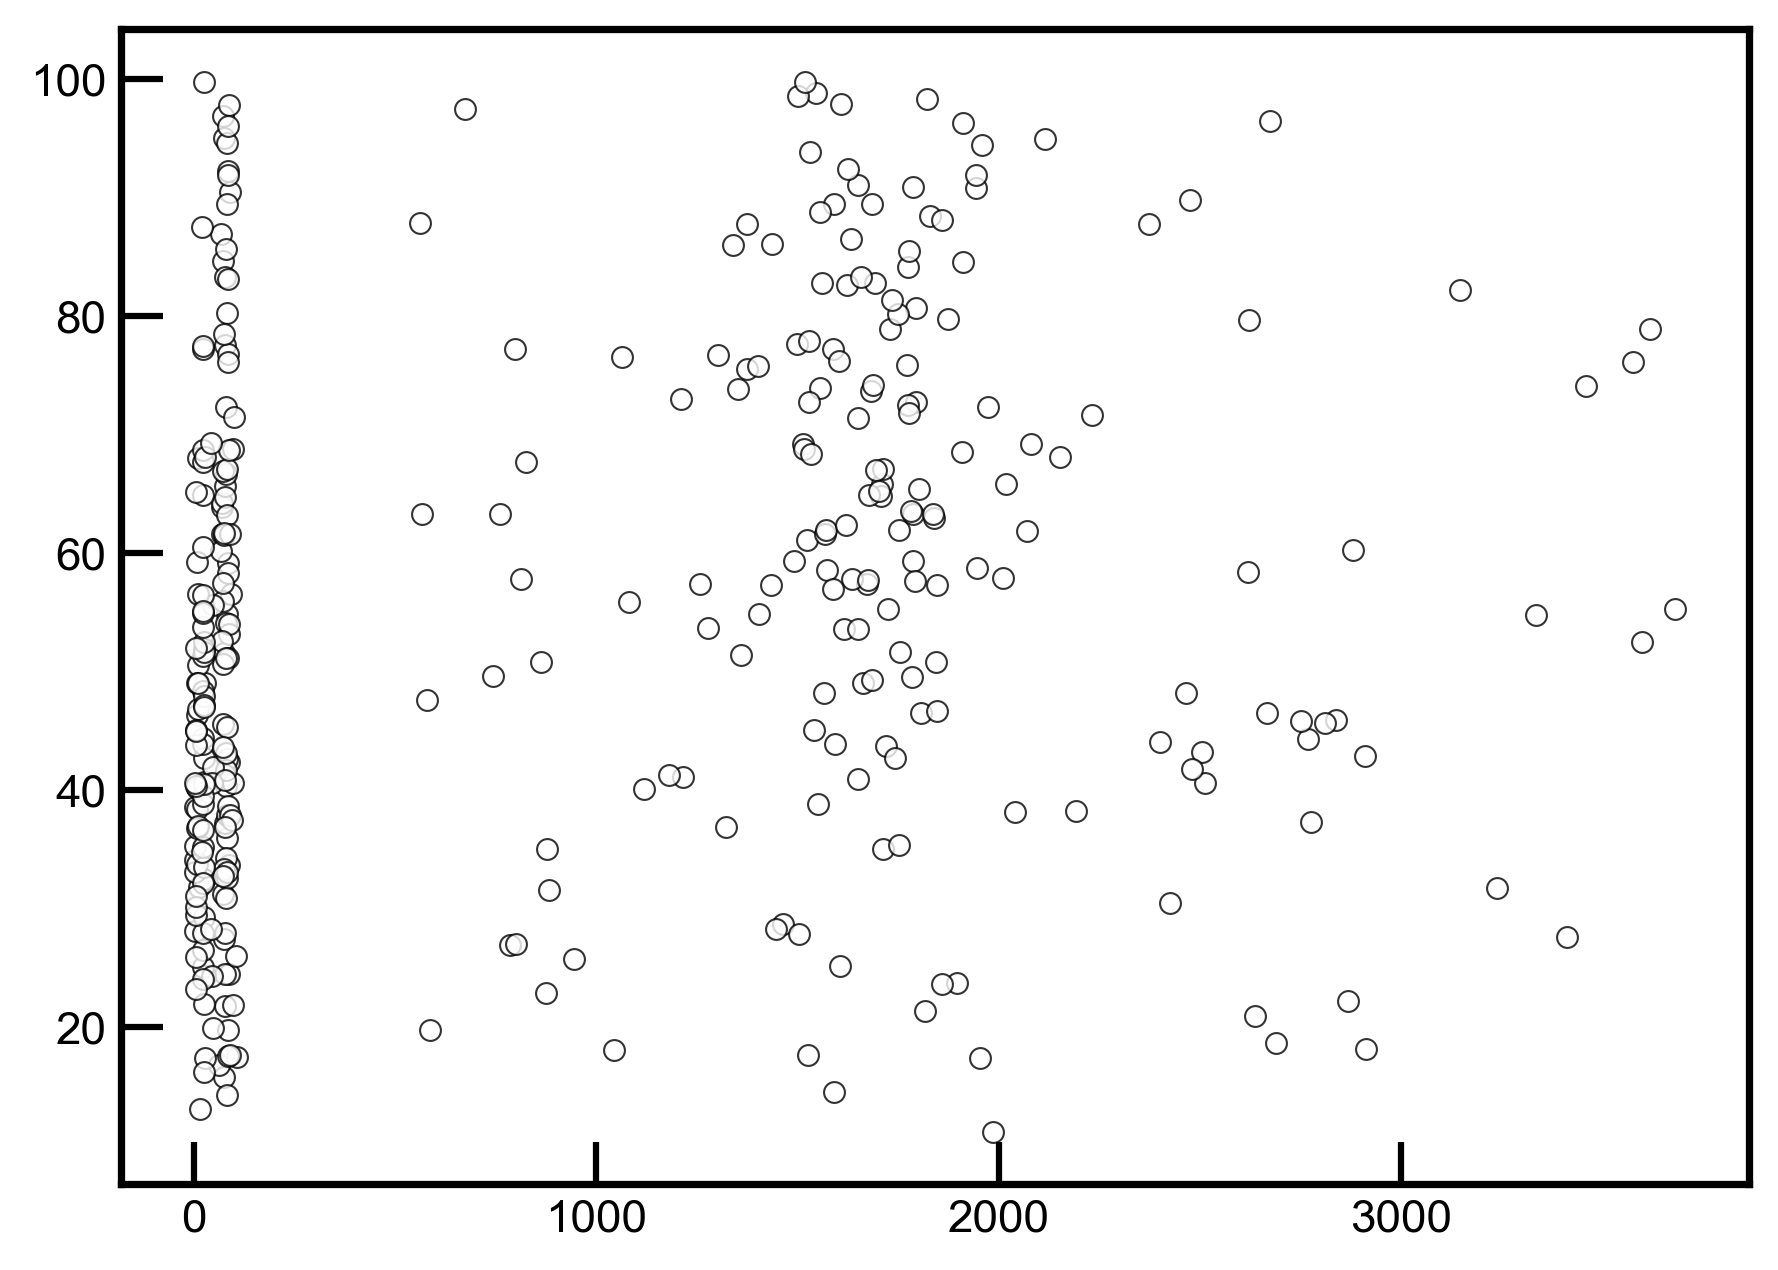

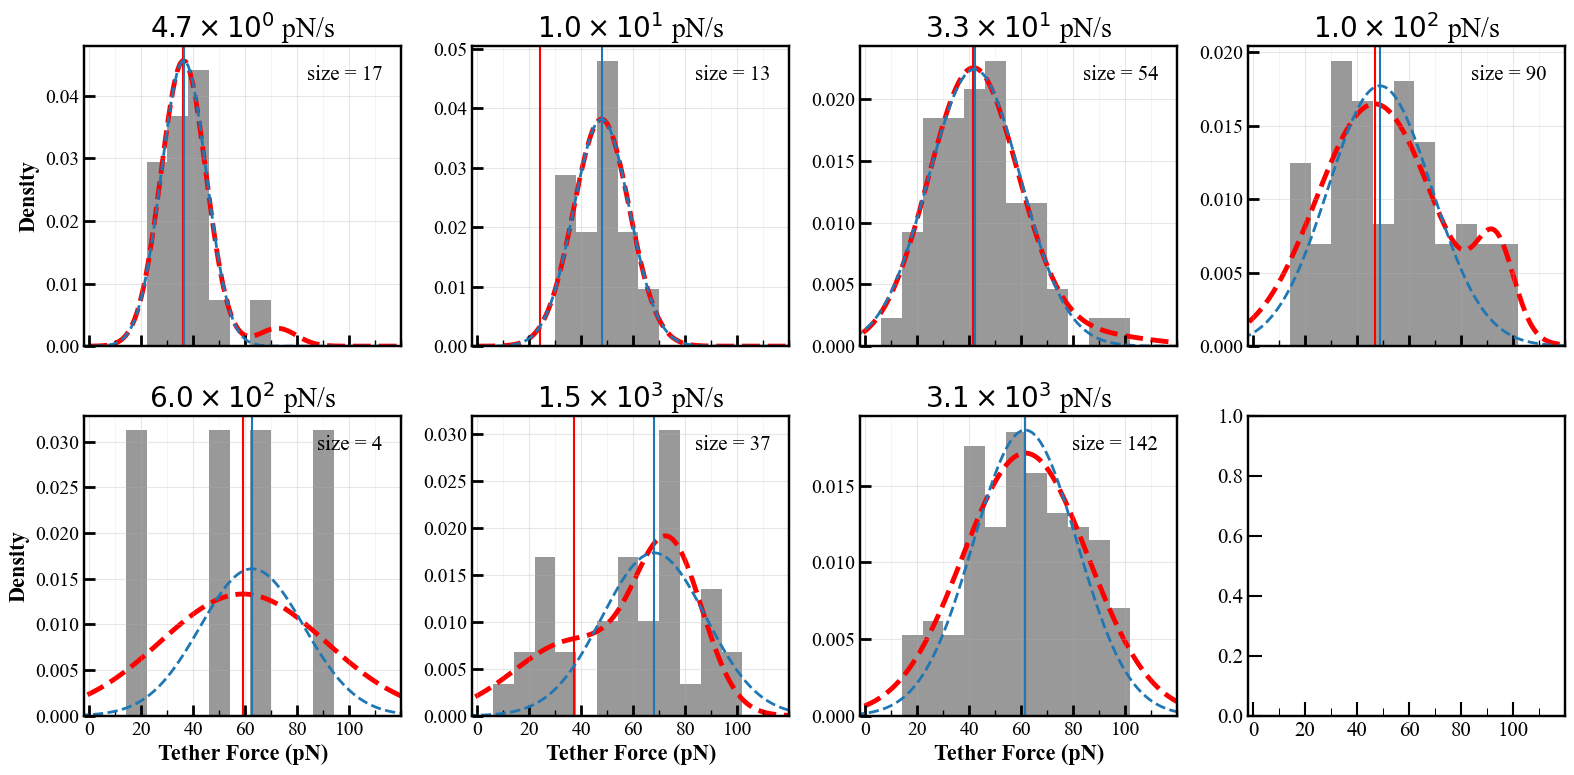

Y-axis range: 11.2 to 99.8 pN


/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_1995/402530093.py:147: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(left = 10e-1)


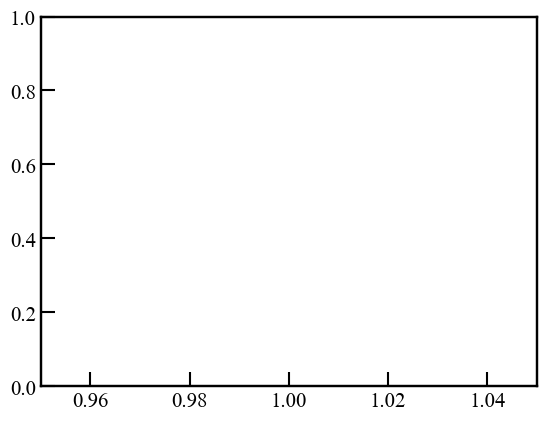

Total selected tether plateaus analyzed: 357
/Users/evillz/Data/article/figures/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.27.06.69_Tethe.svg


In [48]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(7, 5), dpi=300)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False,  # Enable right ticks
    # "ytick.left": True
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points 
ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
          alpha=0.8, s=25, color='white', edgecolors='black', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity_calc'].min()
velocity_max = force_df['velocity_calc'].max()
# First, check your actual data range
print(f"Data velocity range: {force_df['velocity_calc'].min():.1f} - {force_df['velocity_calc'].max():.1f} µm/s")

# Define your custom velocity bin edges (µm/s)
velocity_bin_edges = np.array([1, 3, 6, 15, 30, 200, 1000, 2000, 10000]) 

# 3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]

# OR better: Set the upper bound based on your max velocity
max_velocity = force_df['velocity_calc'].max()
print(f"Using bin edges: {velocity_bin_edges}")

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges, right = True) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Create bin labels for display
velocity_bin_labels = []
for i in range(len(velocity_bin_edges) - 1):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]
# Calculate binned means and standard deviations
means_df_2 = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_sem=('force_clean', 'sem'),

    force_count=('force_clean', 'count'),
    bin_label=('velocity_bin_label', 'first'),
    lifetime_m_clean_mean=('lifetime_m_clean', 'mean'),
    lifetime_m_clean_std=('lifetime_m_clean', 'std'),
    lifetime_m_clean_count=('lifetime_m_clean', 'count'),
    lifetime_s_clean_mean=('lifetime_s_clean', 'mean'),
    lifetime_s_clean_std=('lifetime_s_clean', 'std'),
    lifetime_s_clean_count=('lifetime_s_clean', 'count'),
).reset_index()
_, df_afs_avg = make_hist_dfs_AFS(force_df, **plot_kwargs)
plt.show()



# 3. Plot means with error bars (standard deviation) using bin centers
# ax.errorbar(means_df_2['velocity_bin_center'], means_df_2['force_mean'], 
#            yerr=means_df_2['force_sem'], 
#            fmt='o', color='white', markersize=8, markeredgecolor='black', 
#            markeredgewidth=2, ecolor='black', capsize=5, capthick=1.5,
#            label=f'Binned Mean ± SD (n={len(means_df_2)} bins)', zorder=5)

error_afs = ax.errorbar(df_afs_avg['avg_LDR'], df_afs_avg['avg_gauss'], yerr=df_afs_avg['sem_gauss'],
                         xerr=[df_afs_avg['ldr_lower'], df_afs_avg['ldr_upper']], label=' ', elinewidth=1, fmt='o', markersize=6, capsize=3, zorder=20, color='black', markerfacecolor='snow')







# 4. Fit linear trend to binned means only
if len(means_df_2) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df_2['velocity_bin_center'])
    force_clean_means = means_df_2['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_clean_means)
    
    # Generate trend line
    vel_min = max(means_df_2['velocity_bin_center'].min(), 1)
    vel_max = means_df_2['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'black','-', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df_2)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_clean_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.2, color='black',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
# ax.set_title("Tether Force vs Velocity\n(Scatter + Binned Mean Values + Linear Trend to Binned Means)", 
            # fontsize=14, fontweight='bold')
ax.set_xscale('log')
# ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)

# Fix y-axis tick labels
ax.tick_params(axis='x', labelsize=16, which='both', labelbottom=True)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16, which='both', labelleft=True, labelcolor='black', color='black')  # Y-axis tick labels

# Set y-axis ticks based on your data range
y_min = force_df['force_clean'].min()
y_max = force_df['force_clean'].max()
print(f"Y-axis range: {y_min:.1f} to {y_max:.1f} pN")

# Create nice y-axis tick values
y_ticks = [10,30,50,70,90,110]  # X MAJOR TICKS
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.0f}' for tick in y_ticks])

ax.yaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 2 units

# Ensure y-axis is visible
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)

plt.show()

#print how many samples
print(f"Total selected tether plateaus analyzed: {len(force_df)}")

# save as svg file
save_plots = False
dir_path = '/Users/evillz/Data/article/figures'

fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_Tethe.svg')
print (fig_path)
if save_plots:
    fig.savefig(fig_path, format='svg', dpi=600, transparent=True)
    # plt.show()

-1
the mode froce :34.0
0
the mode froce :42.0
1
the mode froce :50.0
2
the mode froce :50.0
3
the mode froce :34.0
4
the mode froce :26.0
5
the mode froce :74.0
6
the mode froce :42.0


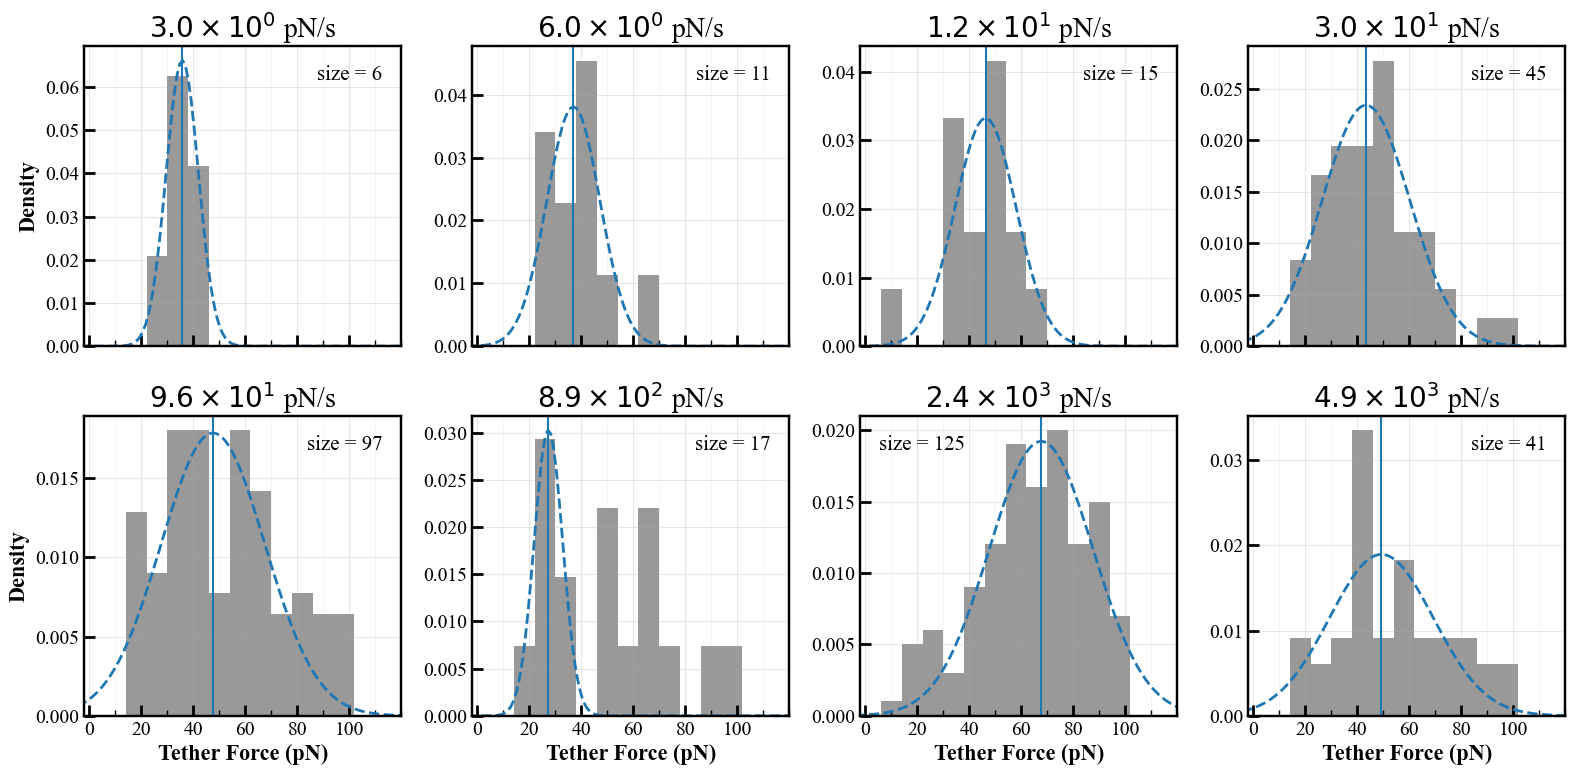

In [49]:
fig_dist_afs, df_afs_avg = make_hist_dfs_tether(force_df, **plot_kwargs)
plt.show()

Data velocity range: 2.3 - 3680.7 µm/s
Using bin edges: [    1     3     6    15    30   200  1000  2000 10000]
Y-axis range: 11.2 to 99.8 pN


<Figure size 2100x1500 with 0 Axes>

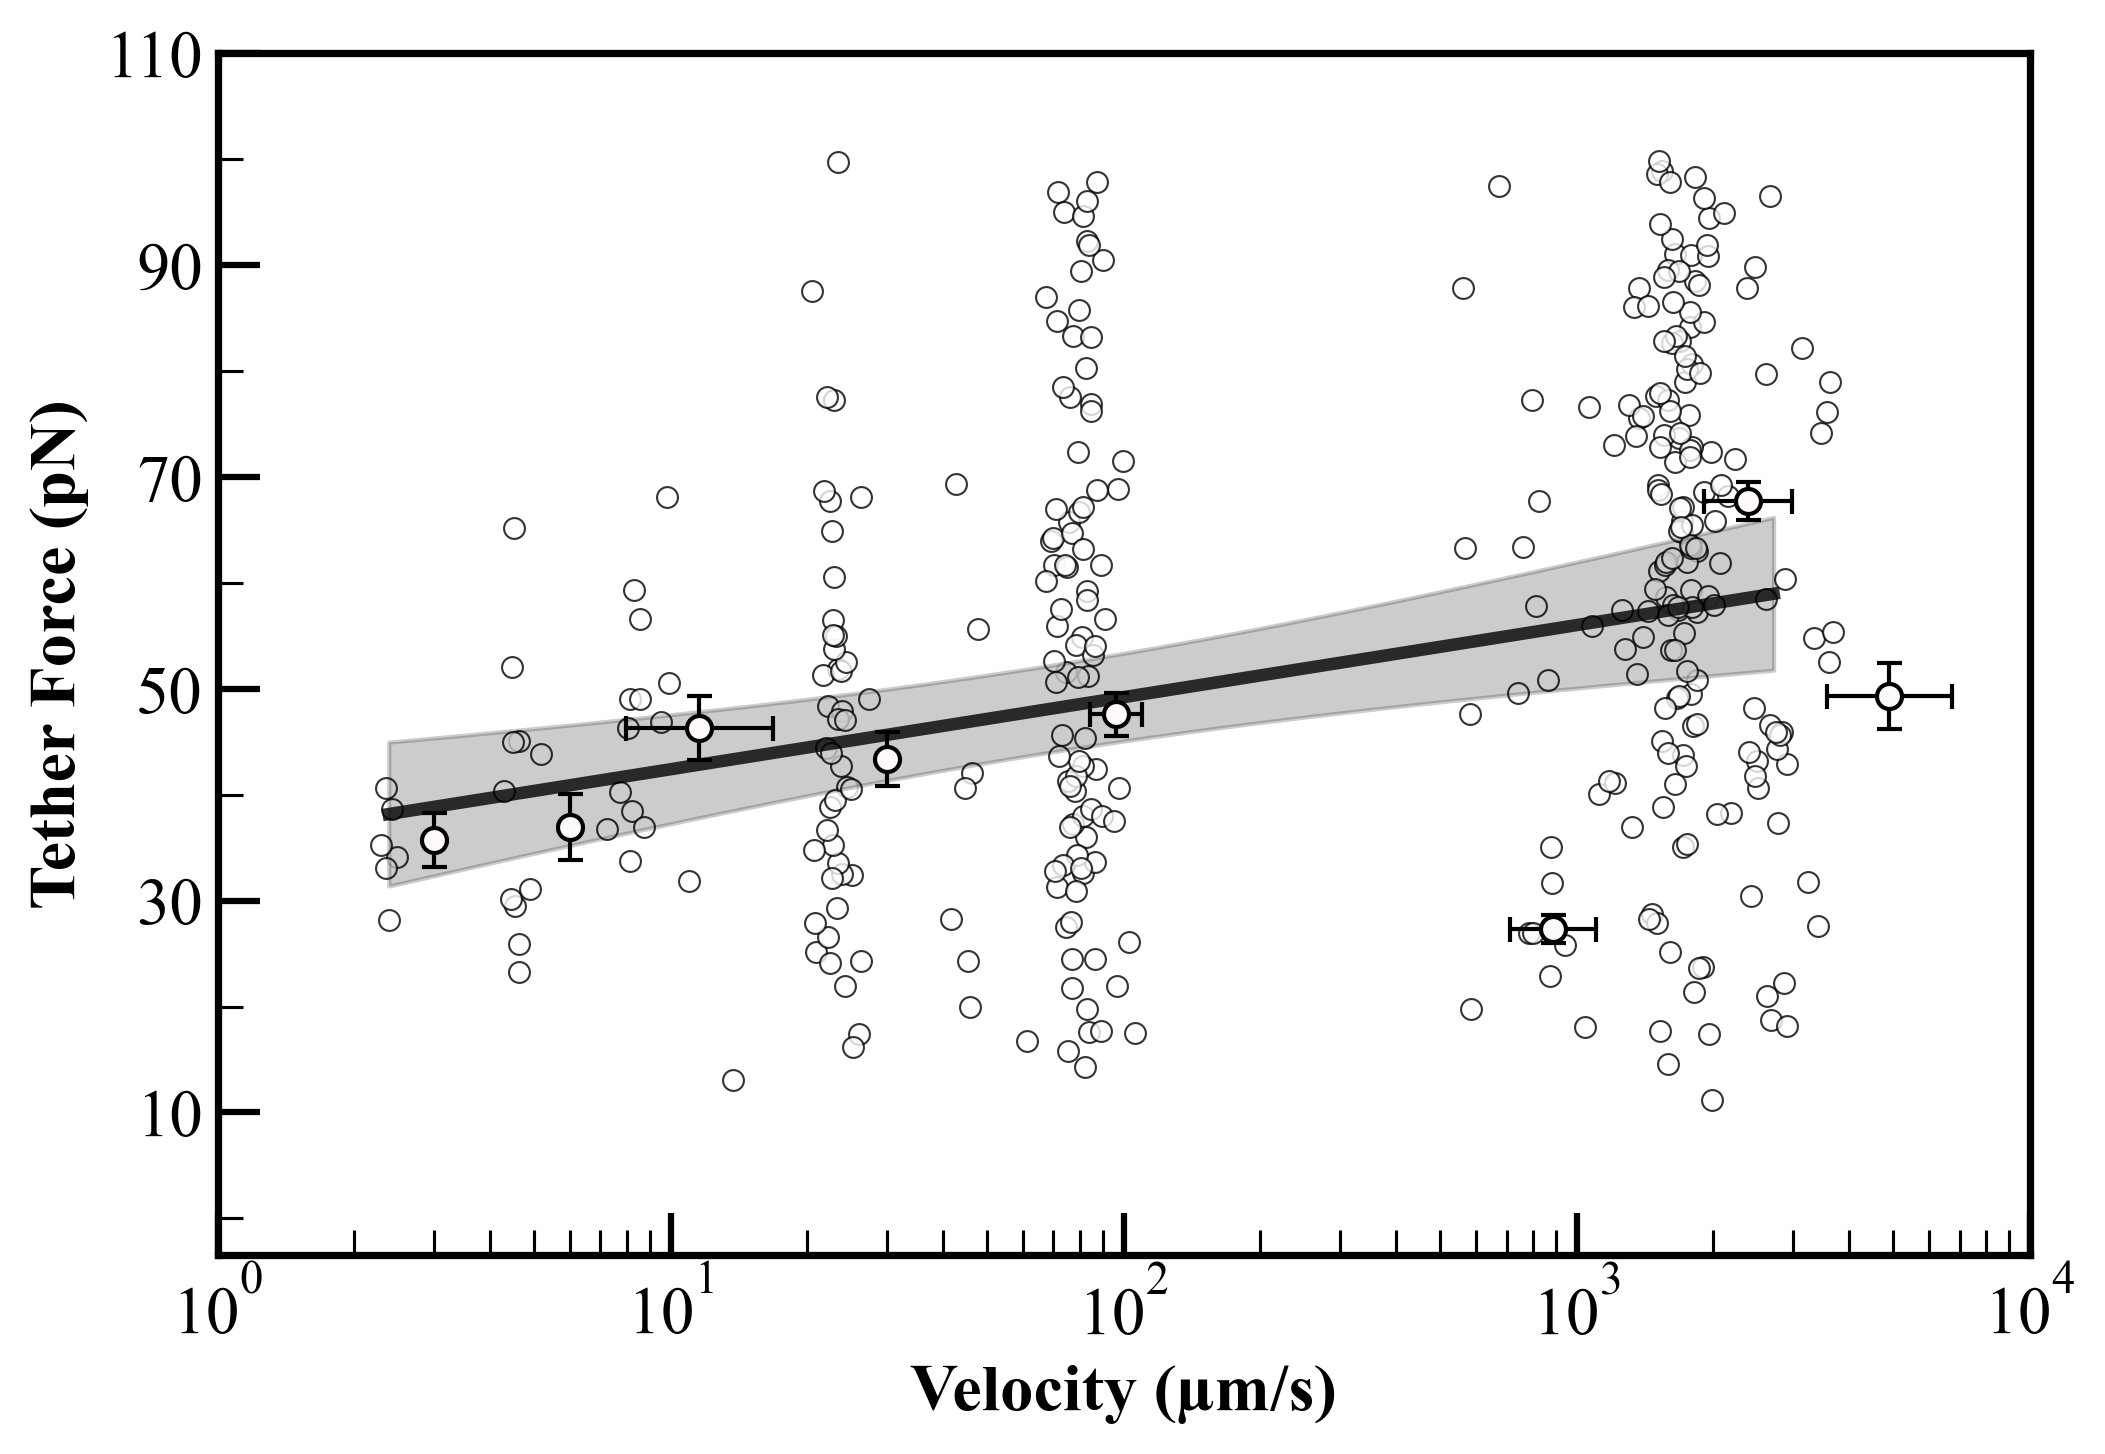

Total selected tether plateaus analyzed: 357
/Users/evillz/Data/article/figures/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.27.06.69_Tethe.svg


In [50]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(7, 5), dpi=300)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False,  # Enable right ticks
    # "ytick.left": True
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points 
ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
          alpha=0.8, s=25, color='white', edgecolors='black', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity_calc'].min()
velocity_max = force_df['velocity_calc'].max()
# First, check your actual data range
print(f"Data velocity range: {force_df['velocity_calc'].min():.1f} - {force_df['velocity_calc'].max():.1f} µm/s")

# Define your custom velocity bin edges (µm/s)
velocity_bin_edges = np.array([1, 3, 6, 15, 30, 200, 1000, 2000, 10000]) 

# 3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]

# OR better: Set the upper bound based on your max velocity
max_velocity = force_df['velocity_calc'].max()
print(f"Using bin edges: {velocity_bin_edges}")

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges, right = True) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Create bin labels for display
velocity_bin_labels = []
for i in range(len(velocity_bin_edges) - 1):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]
# Calculate binned means and standard deviations
means_df_2 = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_sem=('force_clean', 'sem'),

    force_count=('force_clean', 'count'),
    bin_label=('velocity_bin_label', 'first'),
    lifetime_m_clean_mean=('lifetime_m_clean', 'mean'),
    lifetime_m_clean_std=('lifetime_m_clean', 'std'),
    lifetime_m_clean_count=('lifetime_m_clean', 'count'),
    lifetime_s_clean_mean=('lifetime_s_clean', 'mean'),
    lifetime_s_clean_std=('lifetime_s_clean', 'std'),
    lifetime_s_clean_count=('lifetime_s_clean', 'count'),
).reset_index()




# 3. Plot means with error bars (standard deviation) using bin centers
# ax.errorbar(means_df_2['velocity_bin_center'], means_df_2['force_mean'], 
#            yerr=means_df_2['force_sem'], 
#            fmt='o', color='white', markersize=8, markeredgecolor='black', 
#            markeredgewidth=2, ecolor='black', capsize=5, capthick=1.5,
#            label=f'Binned Mean ± SD (n={len(means_df_2)} bins)', zorder=5)


error_afs = ax.errorbar(df_afs_avg['avg_LDR'], df_afs_avg['avg_gauss'], yerr=df_afs_avg['sem_gauss'],
                         xerr=[df_afs_avg['ldr_lower'], df_afs_avg['ldr_upper']], label=' ', elinewidth=1, fmt='o', markersize=6, capsize=3, zorder=20, color='black', markerfacecolor='snow')







# 4. Fit linear trend to binned means only
if len(means_df_2) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df_2['velocity_bin_center'])
    force_clean_means = means_df_2['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_clean_means)
    
    # Generate trend line
    vel_min = max(means_df_2['velocity_bin_center'].min(), 1)
    vel_max = means_df_2['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'black','-', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df_2)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_clean_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.2, color='black',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
# ax.set_title("Tether Force vs Velocity\n(Scatter + Binned Mean Values + Linear Trend to Binned Means)", 
            # fontsize=14, fontweight='bold')
ax.set_xscale('log')
# ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)

# Fix y-axis tick labels
ax.tick_params(axis='x', labelsize=16, which='both', labelbottom=True)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16, which='both', labelleft=True, labelcolor='black', color='black')  # Y-axis tick labels

# Set y-axis ticks based on your data range
y_min = force_df['force_clean'].min()
y_max = force_df['force_clean'].max()
print(f"Y-axis range: {y_min:.1f} to {y_max:.1f} pN")

# Create nice y-axis tick values
y_ticks = [10,30,50,70,90,110]  # X MAJOR TICKS
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.0f}' for tick in y_ticks])

ax.yaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 2 units

# Ensure y-axis is visible
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)

plt.show()

#print how many samples
print(f"Total selected tether plateaus analyzed: {len(force_df)}")

# save as svg file
save_plots = False
dir_path = '/Users/evillz/Data/article/figures'

fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_Tethe.svg')
print (fig_path)
if save_plots:
    fig.savefig(fig_path, format='svg', dpi=600, transparent=True)
    # plt.show()

Data velocity range: 2.3 - 3680.7 µm/s
Using bin edges: [    1     3     6    15    30   200  1000  2000 10000]
Y-axis range: 11.2 to 99.8 pN
Y-axis range: 11.2 to 99.8 pN


<Figure size 2100x1500 with 0 Axes>

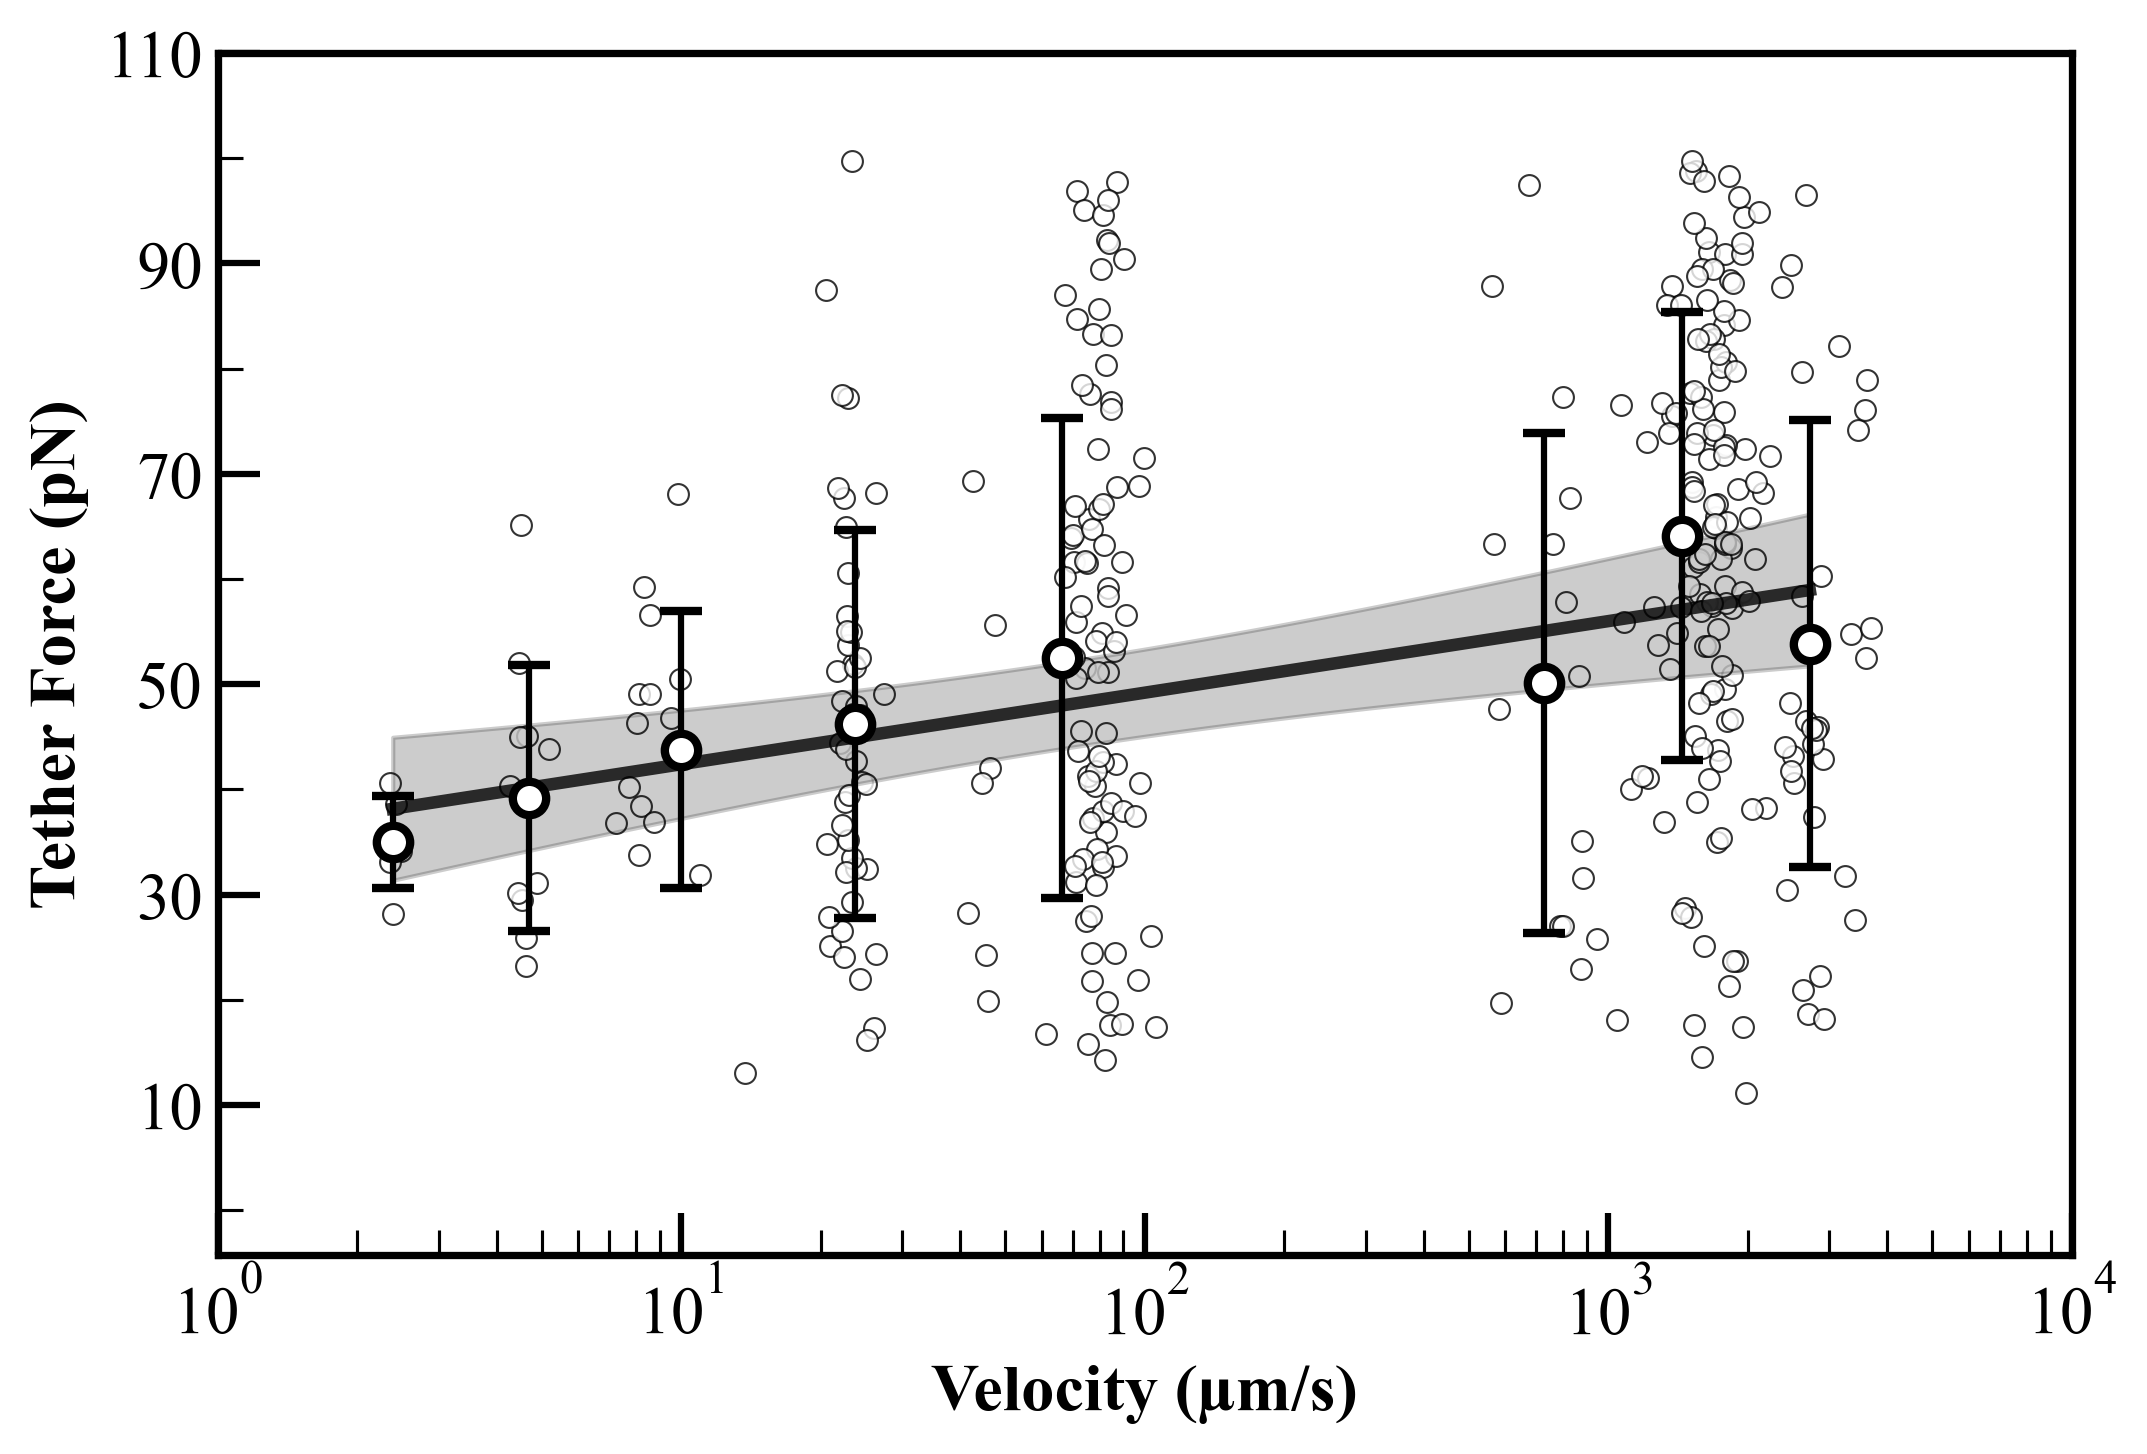

/Users/evillz/Github/LVillanueva_article1/figures/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.27.06.69_TetherForce.svg


In [51]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(7, 5), dpi=300)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False,  # Enable right ticks
    # "ytick.left": True
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points 
ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
          alpha=0.8, s=25, color='white', edgecolors='black', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity_calc'].min()
velocity_max = force_df['velocity_calc'].max()
# First, check your actual data range
print(f"Data velocity range: {force_df['velocity_calc'].min():.1f} - {force_df['velocity_calc'].max():.1f} µm/s")

# Define your custom velocity bin edges (µm/s)
# velocity_bin_edges = np.array([2, 3, 6, 10, 50, 100, 3000, 6000, 7000]) 

# 3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]

# OR better: Set the upper bound based on your max velocity
max_velocity = force_df['velocity_calc'].max()
print(f"Using bin edges: {velocity_bin_edges}")

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges, right = True) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Create bin labels for display
velocity_bin_labels = []
for i in range(len(velocity_bin_edges) - 1):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]
# Calculate binned means and standard deviations
means_df_2 = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_sem=('force_clean', 'sem'),

    force_count=('force_clean', 'count'),
    bin_label=('velocity_bin_label', 'first'),
    lifetime_m_clean_mean=('lifetime_m_clean', 'mean'),
    lifetime_m_clean_std=('lifetime_m_clean', 'std'),
    lifetime_m_clean_count=('lifetime_m_clean', 'count'),
    lifetime_s_clean_mean=('lifetime_s_clean', 'mean'),
    lifetime_s_clean_std=('lifetime_s_clean', 'std'),
    lifetime_s_clean_count=('lifetime_s_clean', 'count'),
).reset_index()




# 3. Plot means with error bars (standard deviation) using bin centers
ax.errorbar(means_df_2['velocity_bin_center'], means_df_2['force_mean'], 
           yerr=means_df_2['force_std'], 
           fmt='o', color='white', markersize=8, markeredgecolor='black', 
           markeredgewidth=2, ecolor='black', capsize=5, capthick=1.5,
           label=f'Binned Mean ± SD (n={len(means_df_2)} bins)', zorder=5)


# error_afs = ax.errorbar(df_afs_avg['avg_LDR'], df_afs_avg['bi_modal'], yerr=df_afs_avg['sem_gauss'],
#                          xerr=[df_afs_avg['ldr_lower'], df_afs_avg['ldr_upper']], label=' ', elinewidth=1, fmt='o', markersize=6, capsize=3, zorder=20, color='black', markerfacecolor='snow')







# 4. Fit linear trend to binned means only
if len(means_df_2) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df_2['velocity_bin_center'])
    force_clean_means = means_df_2['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_clean_means)
    
    # Generate trend line
    vel_min = max(means_df_2['velocity_bin_center'].min(), 1)
    vel_max = means_df_2['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'black','-', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df_2)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_clean_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.2, color='black',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
# ax.set_title("Tether Force vs Velocity\n(Scatter + Binned Mean Values + Linear Trend to Binned Means)", 
            # fontsize=14, fontweight='bold')
ax.set_xscale('log')
# ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)

# Fix y-axis tick labels
ax.tick_params(axis='x', labelsize=16, which='both', labelbottom=True)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16, which='both', labelleft=True, labelcolor='black', color='black')  # Y-axis tick labels

# Set y-axis ticks based on your data range
y_min = force_df['force_clean'].min()
y_max = force_df['force_clean'].max()
print(f"Y-axis range: {y_min:.1f} to {y_max:.1f} pN")

# Create nice y-axis tick values
y_ticks = [10,30,50,70,90,110]  # X MAJOR TICKS
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{tick:.0f}' for tick in y_ticks])

ax.yaxis.set_minor_locator(MultipleLocator(10))  # Minor ticks every 2 units

# Ensure y-axis is visible
ax.yaxis.set_visible(True)
ax.spines['left'].set_visible(True)

plt.show()


# save as svg file
save_plots = False
dir_path = '/Users/evillz/Github/LVillanueva_article1/figures'

fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_TetherForce.svg')
print (fig_path)
if save_plots:
    fig.savefig(fig_path, format='svg', dpi=600, transparent=True)
    # plt.show()

-1
the mode froce :34.0
0
the mode froce :42.0
1
the mode froce :50.0
2
the mode froce :50.0
3
the mode froce :34.0
4
the mode froce :26.0
5
the mode froce :74.0
6
the mode froce :42.0
/Users/evillz/Github/LVillanueva_article1/figures/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.27.06.69_TetherForce_distribution.svg


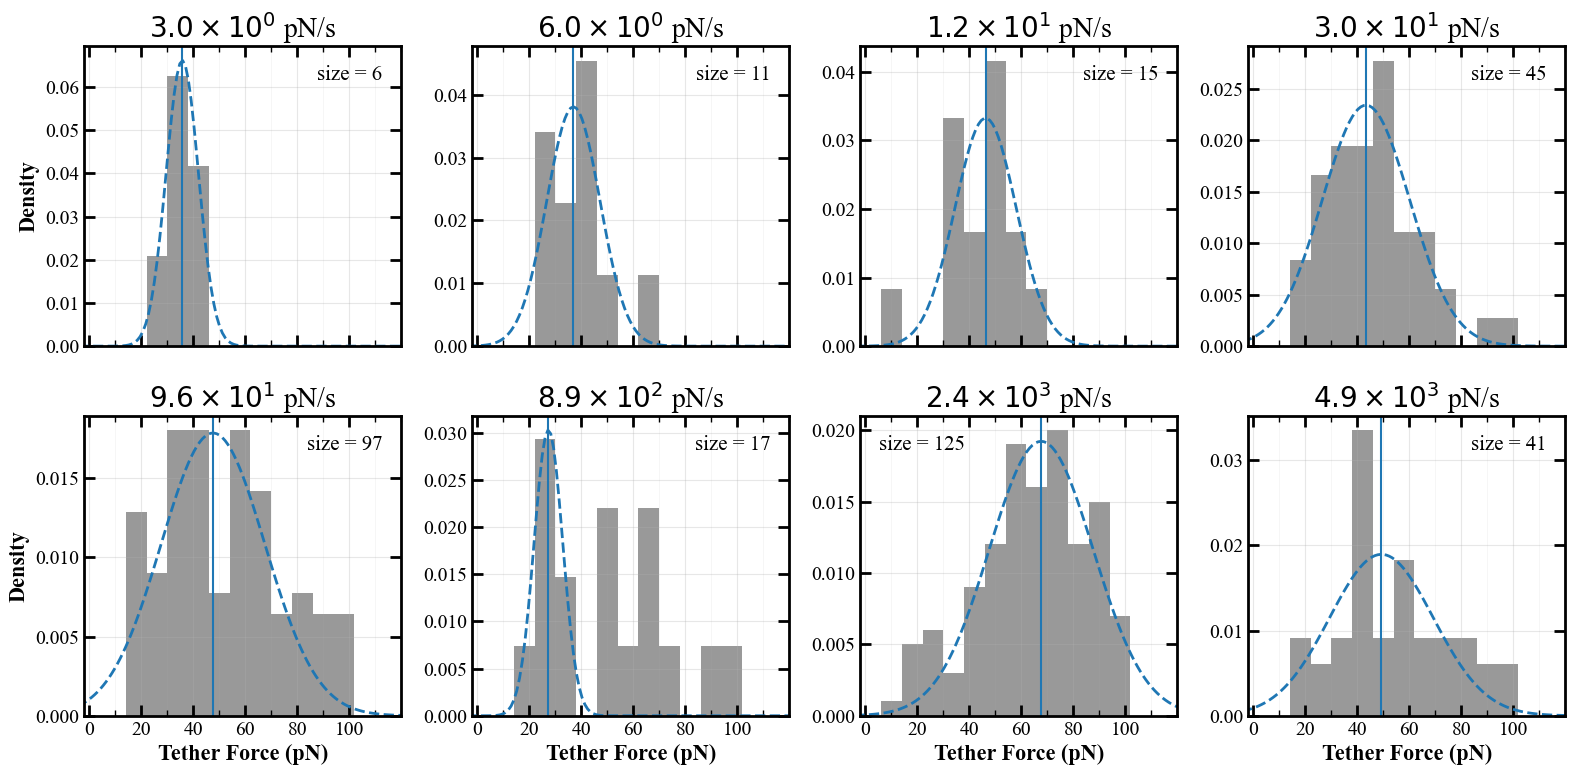

In [57]:
fig_dist_afs, df_afs_avg = make_hist_dfs_tether(force_df, **plot_kwargs)

# save as svg file
save_plots = True
dir_path = '/Users/evillz/Github/LVillanueva_article1/figures'

fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_TetherForce_distribution.svg')
print (fig_path)
if save_plots:
    fig_dist_afs.savefig(fig_path, format='svg', dpi=600, transparent=True)

plt.show()


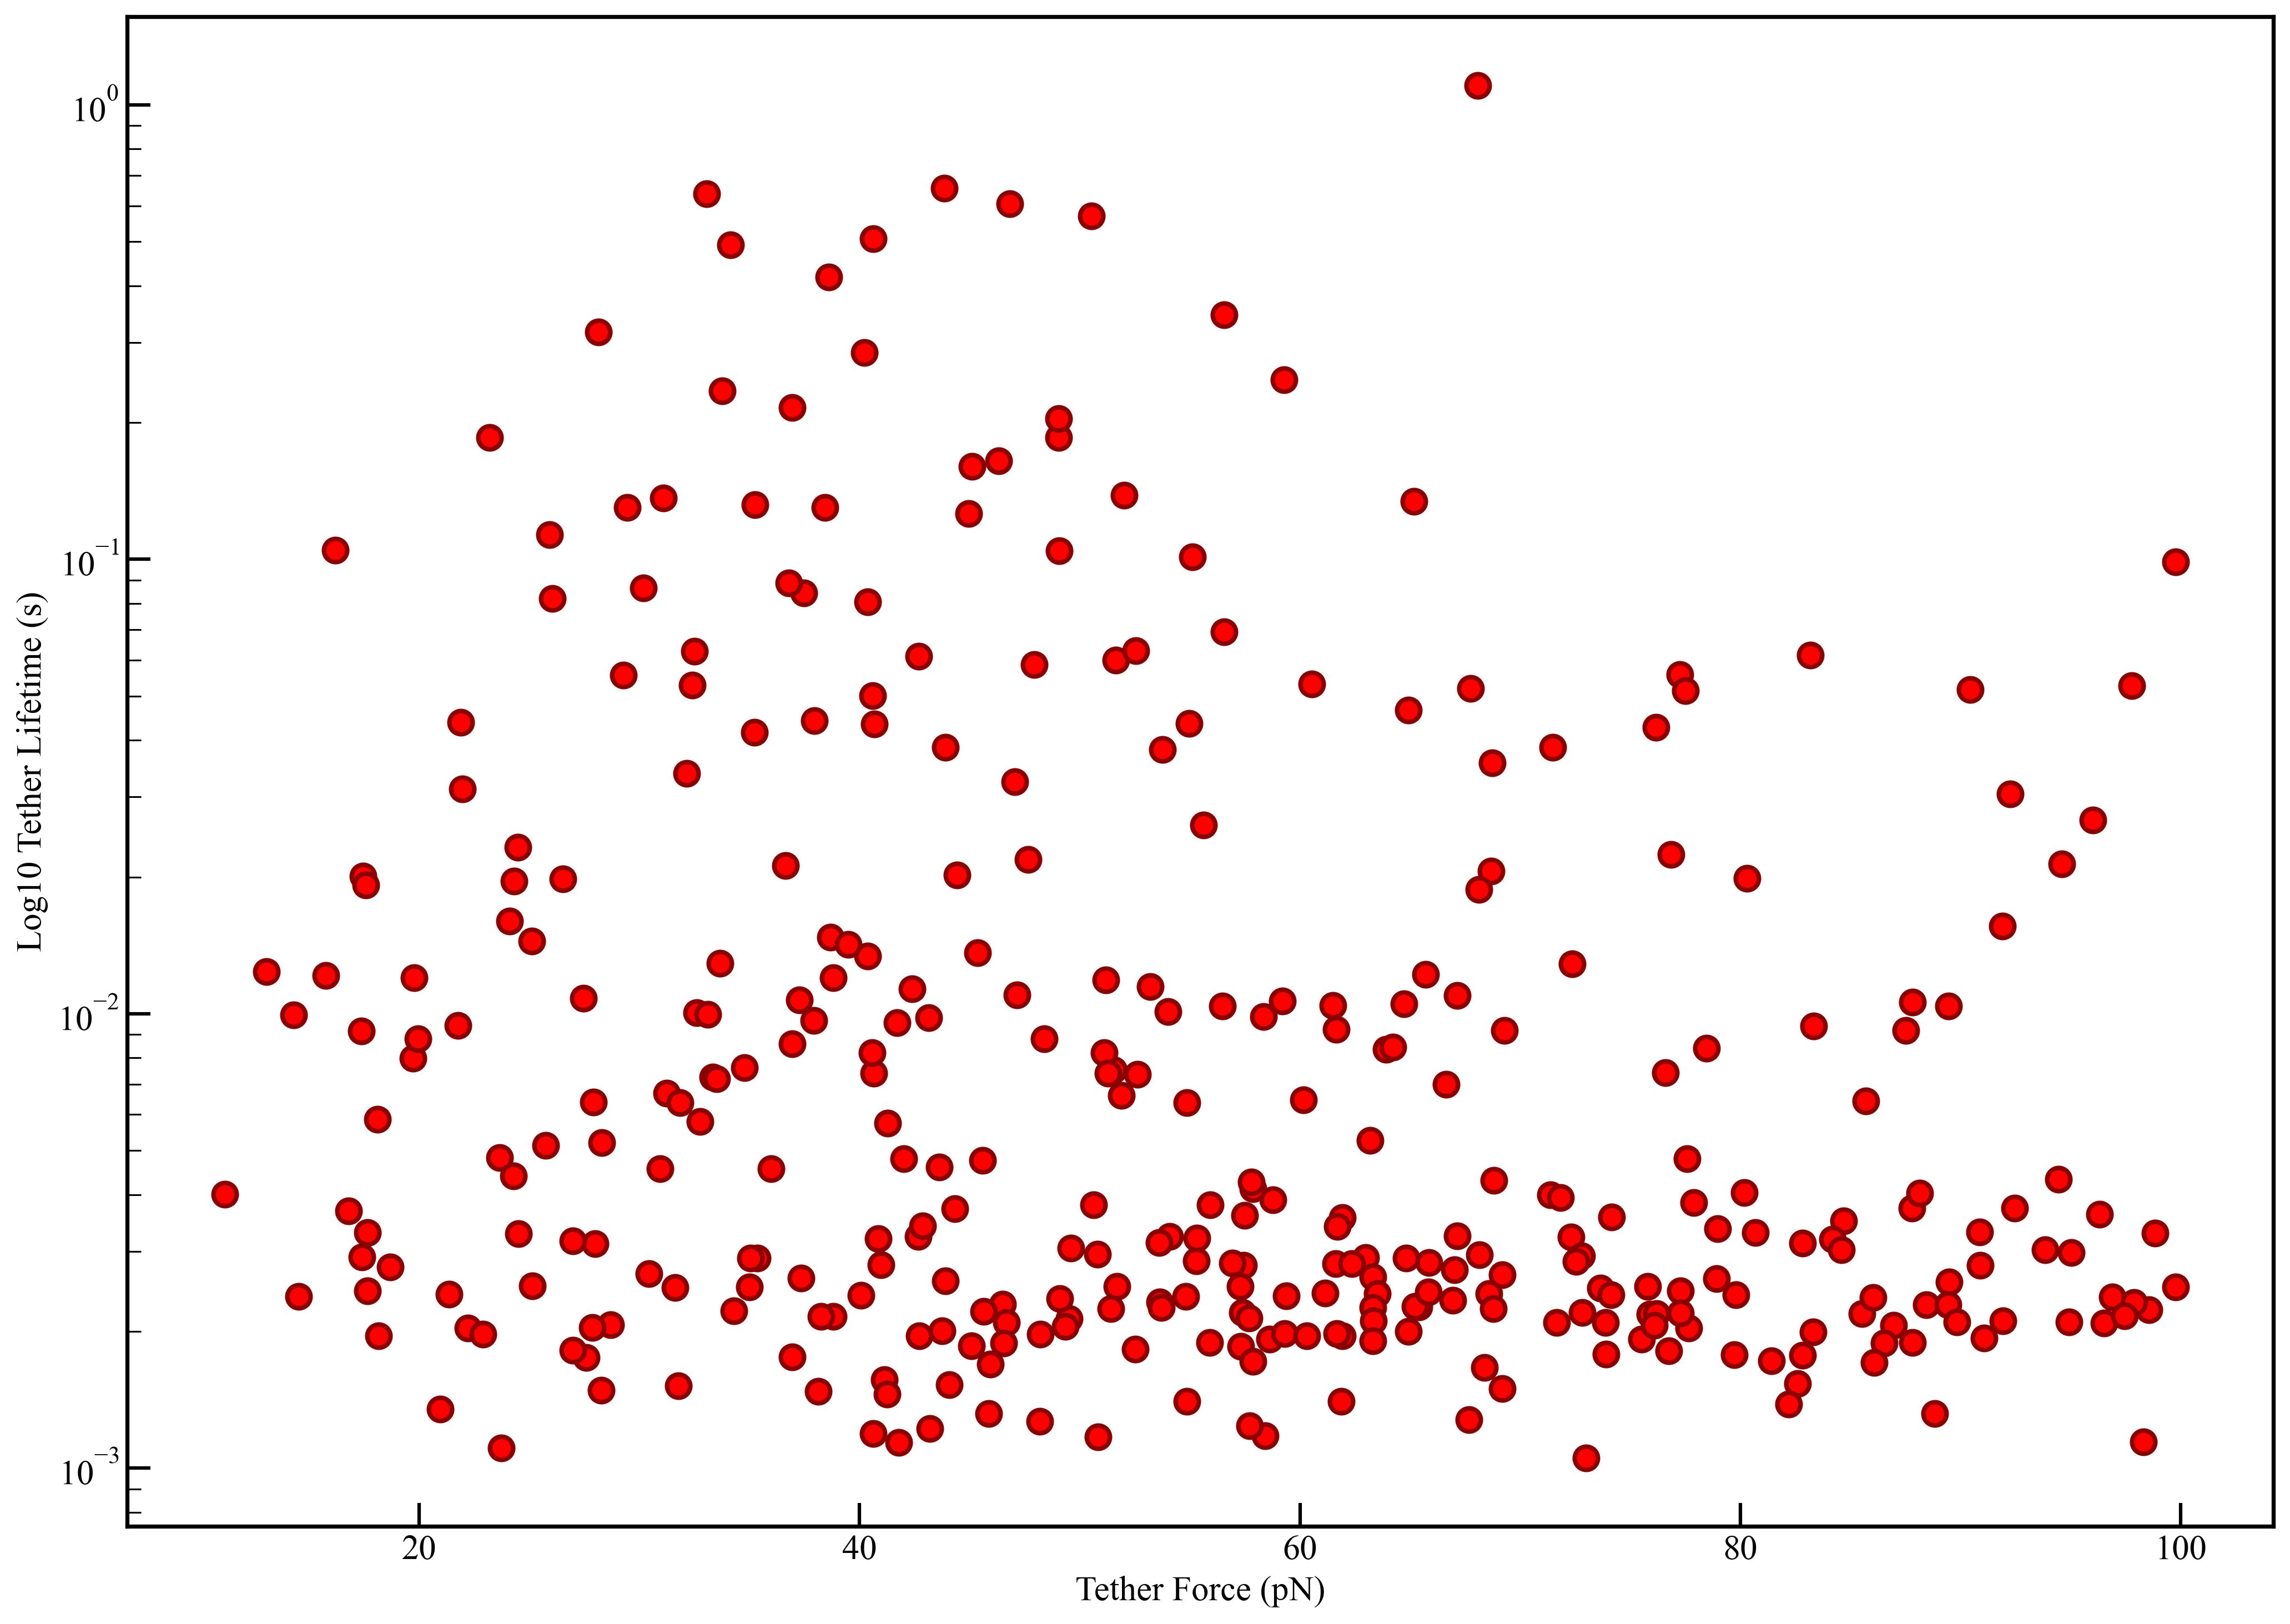

In [53]:
# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)


# 1. Scatter plot of all data points
ax.scatter(force_df['force_clean'], force_df['lifetime_s_clean'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')


# 3. Plot means with error bars
if len(force_df) > 0:
    ax.errorbar(force_df['force_clean'], force_df['lifetime_s_clean'], 
            #    yerr=force_df['lifetime_s_clean_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(force_df)} bins)', zorder=5)

plt.yscale('log')
plt.xlabel("Tether Force (pN)")
plt.ylabel("Log10 Tether Lifetime (s)")
# plt.title("Tether Lifetime vs Tether Force")
plt.tight_layout()
plt.show()


<Figure size 3000x2400 with 0 Axes>

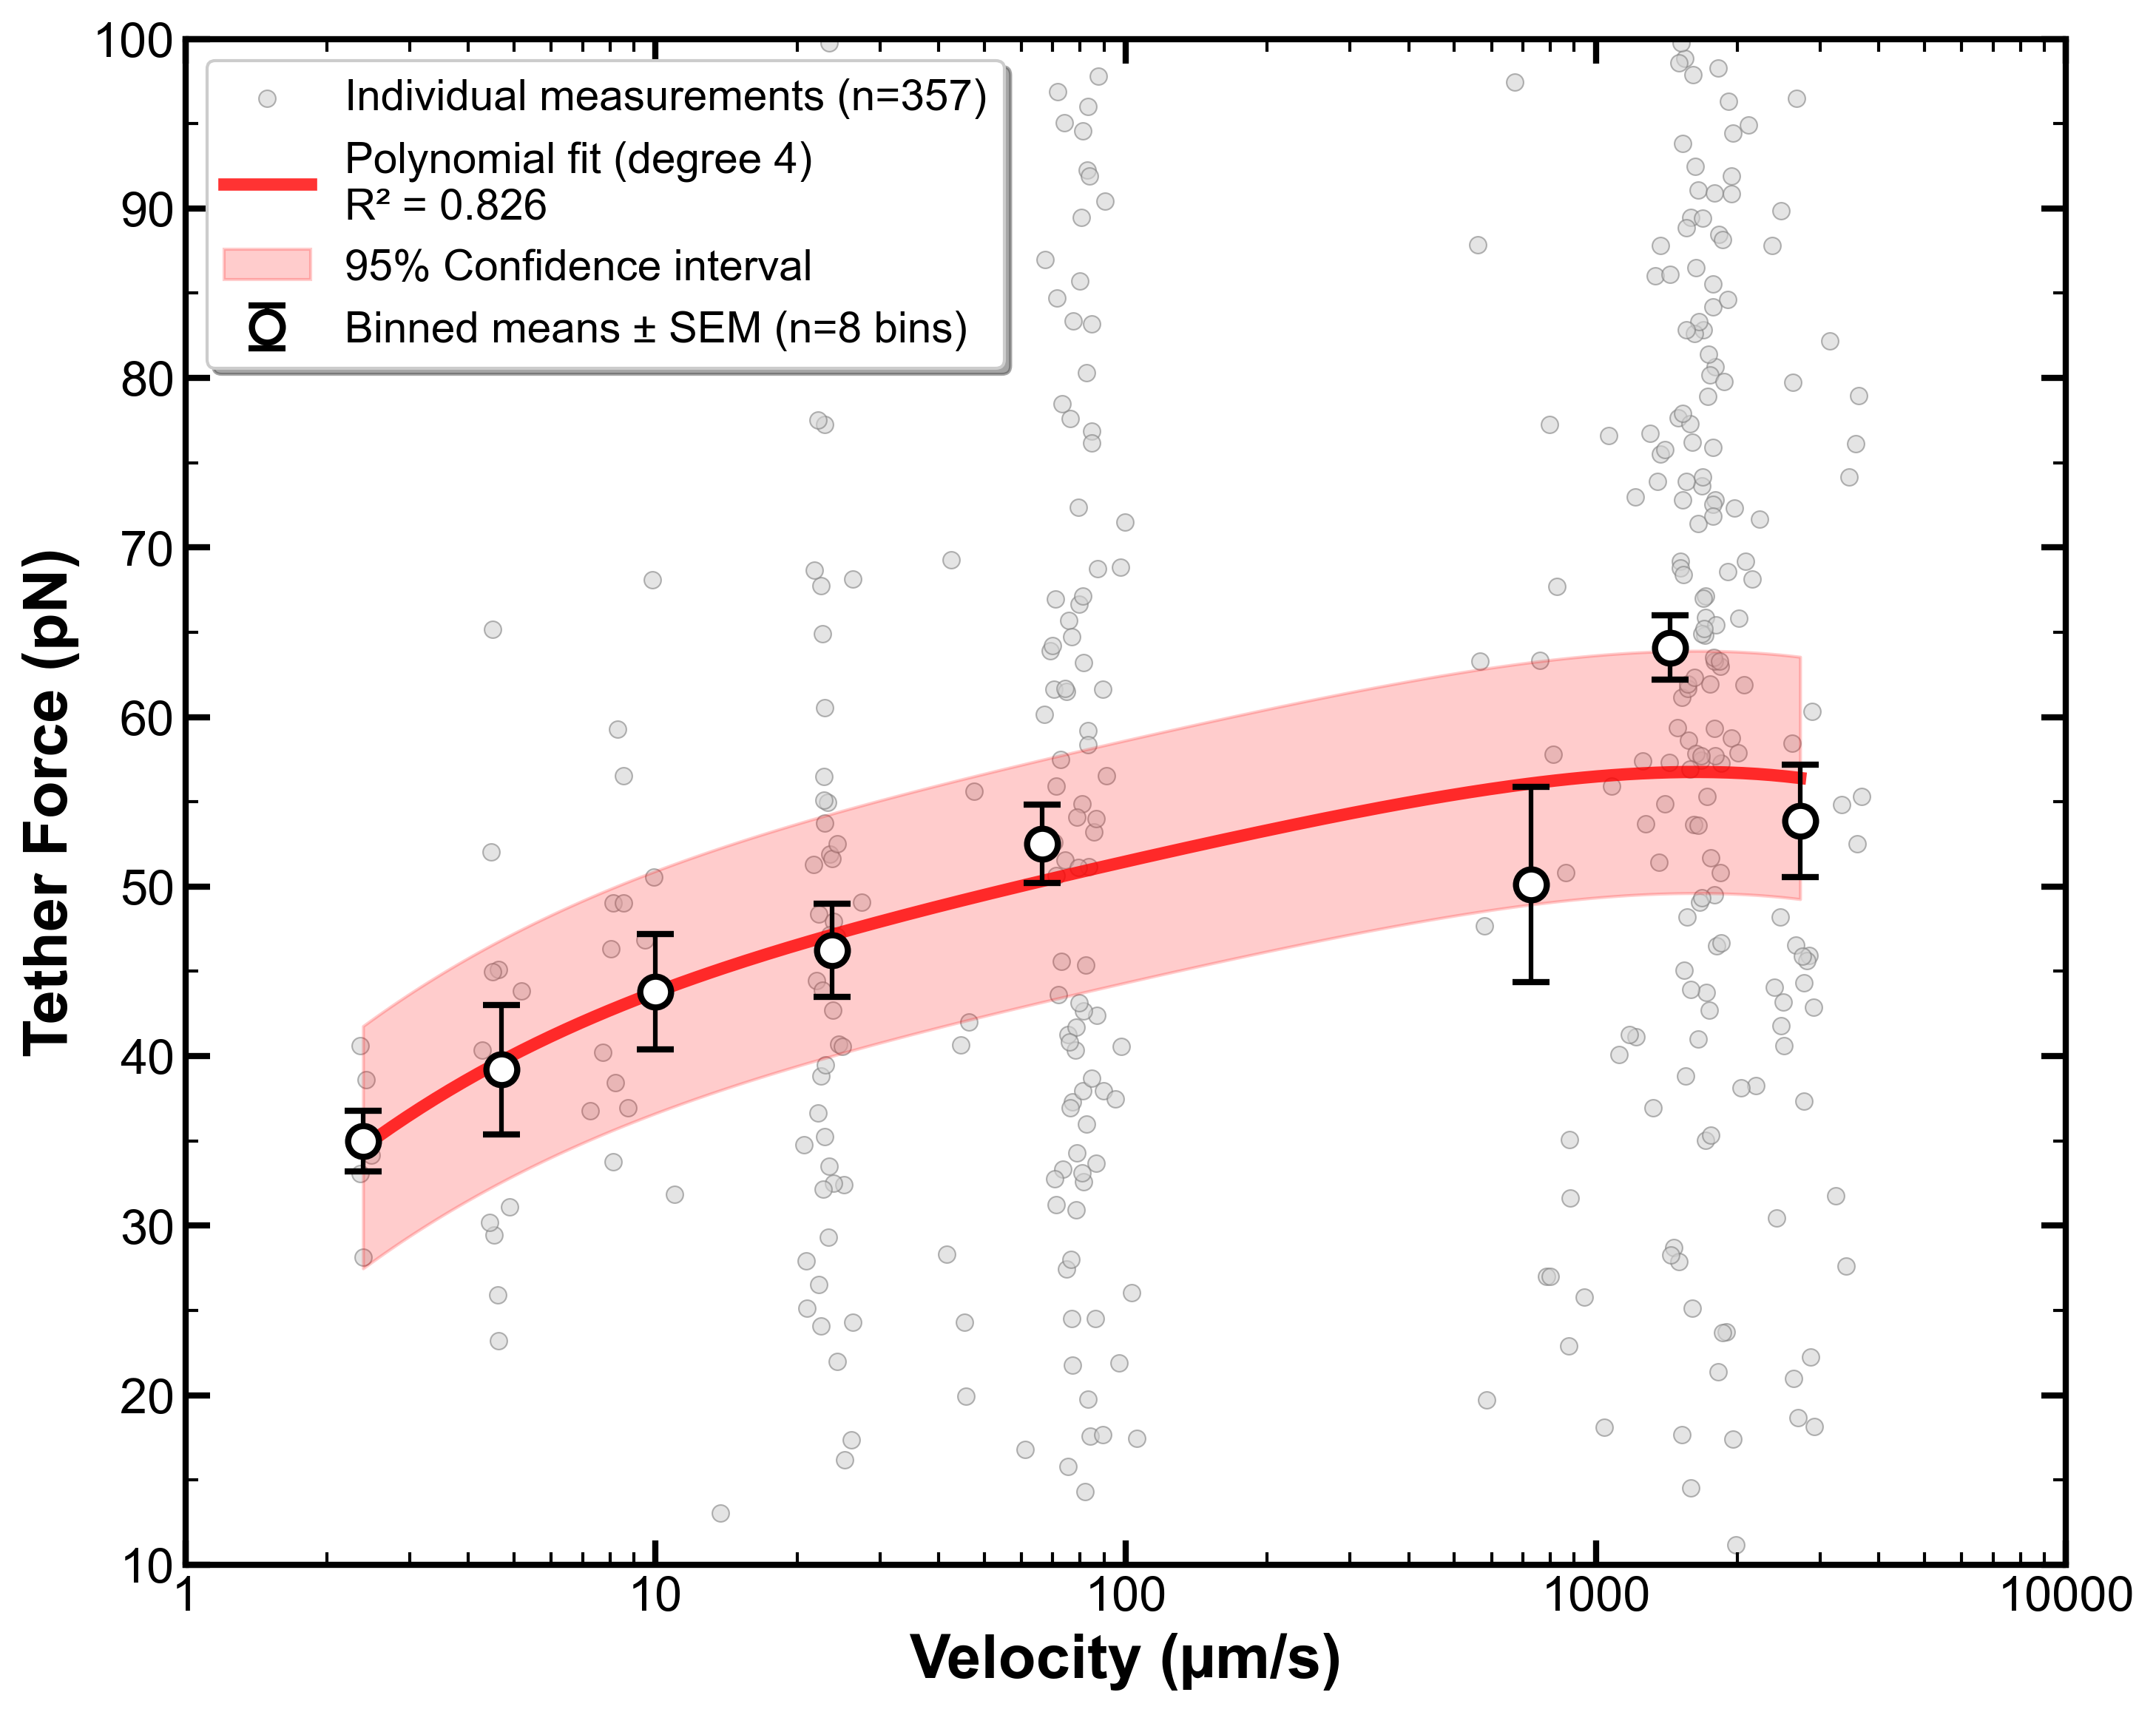


Polynomial fit equation (degree 4):
Force(pN) = 25.038 + 31.083×(log₁₀(velocity))^1 - 17.134×(log₁₀(velocity))^2 + 5.457×(log₁₀(velocity))^3 - 0.678×(log₁₀(velocity))^4
R² = 0.826

Total data points: 357
Binned means used for fit: 8


In [54]:
# Create Tether Force vs Velocity plot with polynomial fit
import os
import scipy.stats as stats
from scipy.optimize import curve_fit
import numpy.polynomial.polynomial as poly

plt.figure(figsize=(10, 8), dpi=300)
plt.rcParams.update({
    'font.size': 16,
    'axes.linewidth': 2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 1,
    "ytick.minor.width": 1,
    "xtick.top": True,
    "ytick.right": True,
    'font.family': 'Arial'
})

# Create main plot
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# 1. Scatter plot of all data points 
scatter = ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
                    alpha=0.6, s=30, color='lightgray', edgecolors='gray', linewidth=0.5,
                    label=f'Individual measurements (n={len(force_df)})', zorder=1)

# 2. Calculate binned means using existing velocity_bin_edges
velocity_bin_edges = np.array([1, 3, 6, 15, 30, 200, 1000, 2000, 10000])

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges, right=True) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Calculate binned means and standard errors
means_df = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_sem=('force_clean', 'sem'),
    force_count=('force_clean', 'count')
).reset_index()

# Filter out bins with too few data points
means_df = means_df[means_df['force_count'] >= 5]

# 3. Plot binned means with error bars
errorbar_plot = ax.errorbar(means_df['velocity_bin_center'], means_df['force_mean'], 
                           yerr=means_df['force_sem'], 
                           fmt='o', color='black', markersize=10, markerfacecolor='white',
                           markeredgewidth=2, ecolor='black', capsize=6, capthick=2,
                           label=f'Binned means ± SEM (n={len(means_df)} bins)', zorder=5)

# 4. Polynomial fit to the binned data
if len(means_df) >= 4:  # Need at least 4 points for a good polynomial fit
    # Convert to log space for better fitting
    x_data = np.log10(means_df['velocity_bin_center'].values)
    y_data = means_df['force_mean'].values
    
    # Try different polynomial degrees and choose the best one
    degrees = [2, 3, 4]
    best_degree = 2
    best_r2 = -1
    
    for degree in degrees:
        if len(means_df) > degree + 1:  # Need more points than degree
            try:
                # Fit polynomial
                coeffs = np.polyfit(x_data, y_data, degree)
                poly_func = np.poly1d(coeffs)
                y_pred = poly_func(x_data)
                
                # Calculate R²
                ss_res = np.sum((y_data - y_pred) ** 2)
                ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
                r2 = 1 - (ss_res / ss_tot)
                
                if r2 > best_r2:
                    best_r2 = r2
                    best_degree = degree
                    best_coeffs = coeffs
            except:
                continue
    
    # Generate smooth curve for plotting
    x_smooth = np.logspace(np.log10(means_df['velocity_bin_center'].min()), 
                          np.log10(means_df['velocity_bin_center'].max()), 200)
    x_smooth_log = np.log10(x_smooth)
    
    # Apply best polynomial fit
    best_poly = np.poly1d(best_coeffs)
    y_smooth = best_poly(x_smooth_log)
    
    # Plot polynomial fit
    ax.plot(x_smooth, y_smooth, 'red', linewidth=4, alpha=0.8,
           label=f'Polynomial fit (degree {best_degree})\nR² = {best_r2:.3f}', zorder=3)
    
    # Add confidence interval (approximate)
    residuals = y_data - best_poly(x_data)
    std_residual = np.std(residuals)
    
    y_upper = y_smooth + 2 * std_residual
    y_lower = y_smooth - 2 * std_residual
    
    ax.fill_between(x_smooth, y_lower, y_upper, alpha=0.2, color='red',
                   label='95% Confidence interval', zorder=2)

# 5. Formatting to match the reference plot
ax.set_xscale('log')
ax.set_xlabel("Velocity (µm/s)", fontsize=20, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=20, fontweight='bold')

# Set axis limits to match the reference
ax.set_xlim(1, 10000)
ax.set_ylim(10, 100)

# Customize ticks
ax.tick_params(axis='both', labelsize=16, which='major', 
              length=8, width=2, color='black', labelcolor='black')
ax.tick_params(axis='both', which='minor', 
              length=4, width=1, color='black')

# Set specific tick positions
ax.set_xticks([1, 10, 100, 1000, 10000])
ax.set_xticklabels(['1', '10', '100', '1000', '10000'])

ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_yticklabels([f'{int(tick)}' for tick in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]])

# Add minor ticks
from matplotlib.ticker import LogLocator
ax.xaxis.set_minor_locator(LogLocator(subs='all'))
ax.yaxis.set_minor_locator(MultipleLocator(5))

# Add legend
ax.legend(fontsize=14, frameon=True, fancybox=True, shadow=True, loc='upper left')

# Ensure all spines are visible and bold
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_visible(True)

plt.tight_layout()
plt.show()

# Print polynomial equation
if 'best_coeffs' in locals():
    print(f"\nPolynomial fit equation (degree {best_degree}):")
    print("Force(pN) = ", end="")
    for i, coeff in enumerate(reversed(best_coeffs)):
        if i == 0:
            print(f"{coeff:.3f}", end="")
        else:
            sign = "+" if coeff >= 0 else "-"
            print(f" {sign} {abs(coeff):.3f}×(log₁₀(velocity))^{i}", end="")
    print(f"\nR² = {best_r2:.3f}")
    
print(f"\nTotal data points: {len(force_df)}")
print(f"Binned means used for fit: {len(means_df)}")

# Save plot
save_plots = False
if save_plots:
    dir_path = '/Users/evillz/Data/article/figures'
    os.makedirs(dir_path, exist_ok=True)
    fig_path = os.path.join(dir_path, 'tether_force_vs_velocity_polynomial_fit.svg')
    plt.savefig(fig_path, format='svg', dpi=600, transparent=True, bbox_inches='tight')
    print(f"Plot saved to: {fig_path}")

In [55]:
# Comprehensive Model Comparison: Theoretical vs Empirical Fits
# Based on Equation 17: F³ - Ff₀² = (2π)³2c²vₓLc ln(R/r₁)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
import pandas as pd
from sklearn.metrics import r2_score

# Prepare data
x_data = means_df['velocity_bin_center'].values  # velocity (μm/s)
y_data = means_df['force_mean'].values  # force (pN)
y_errors = means_df['force_sem'].values

print("=== THEORETICAL MODEL ANALYSIS ===")
print(f"Data points for fitting: {len(x_data)}")
print(f"Velocity range: {x_data.min():.1f} to {x_data.max():.1f} μm/s")
print(f"Force range: {y_data.min():.1f} to {y_data.max():.1f} pN")
print()

# =================================================================
# MODEL 1: Theoretical Model (Based on Eq. 17)
# Simplified form: F = A + B * ln(v)  
# where A accounts for static force f₀ and B for velocity dependence
# =================================================================

def theoretical_model(v, A, B):
    """
    Theoretical logarithmic model based on Eq. 17
    F = A + B * ln(v)
    where A ~ f₀ (static force)
    and B ~ (2π)³2c²vₓLc (material/geometric parameters)
    """
    return A + B * np.log(v)

# =================================================================
# MODEL 2: Power Law Model
# F = A * v^B (common in biophysics)
# =================================================================

def power_law_model(v, A, B):
    """Power law: F = A * v^B"""
    return A * v**B

# =================================================================
# MODEL 3: Logarithmic Model (Alternative form)
# F = A * ln(v) + B
# =================================================================

def log_model_alt(v, A, B):
    """Alternative logarithmic: F = A * ln(v) + B"""
    return A * np.log(v) + B

# =================================================================
# MODEL 4: Exponential Saturation Model
# F = A * (1 - exp(-v/B)) + C
# =================================================================

def exponential_saturation(v, A, B, C):
    """Exponential saturation: F = A * (1 - exp(-v/B)) + C"""
    return A * (1 - np.exp(-v/B)) + C

# =================================================================
# MODEL 5: Polynomial Models (2nd and 3rd order in log space)
# =================================================================

def polynomial_2nd_log(v, A, B, C):
    """2nd order polynomial in log space: F = A + B*ln(v) + C*(ln(v))²"""
    log_v = np.log(v)
    return A + B * log_v + C * log_v**2

def polynomial_3rd_log(v, A, B, C, D):
    """3rd order polynomial in log space"""
    log_v = np.log(v)
    return A + B * log_v + C * log_v**2 + D * log_v**3
def polynomial_4th_log(v, A, B, C, D, E):
    """4th order polynomial in log space"""
    log_v = np.log(v)
    return A + B * log_v + C * log_v**2 + D * log_v**3 + E * log_v**4
# =================================================================
# FIT ALL MODELS AND COMPARE
# =================================================================

models = {
    'Theoretical (Eq. 17)': {
        'func': theoretical_model,
        'initial_guess': [30, 5],  # A~30pN (baseline force), B~5 (log coefficient)
        'color': 'red',
        'linewidth': 4,
        'theory': True
    },
    'Power Law': {
        'func': power_law_model,
        'initial_guess': [20, 0.1],  # A~20, B~0.1
        'color': 'blue',
        'linewidth': 2,
        'theory': False
    },
    'Log Alternative': {
        'func': log_model_alt,
        'initial_guess': [5, 30],  # A~5, B~30
        'color': 'green',
        'linewidth': 2,
        'theory': False
    },
    'Exponential Saturation': {
        'func': exponential_saturation,
        'initial_guess': [30, 100, 20],  # A~30, B~100, C~20
        'color': 'orange',
        'linewidth': 2,
        'theory': False
    },
    'Polynomial 2nd (log)': {
        'func': polynomial_2nd_log,
        'initial_guess': [30, 5, 0.1],  # A~30, B~5, C~0.1
        'color': 'purple',
        'linewidth': 2,
        'theory': False
    },
    'Polynomial 3rd (log)': {
        'func': polynomial_3rd_log,
        'initial_guess': [30, 5, 0.1, 0.01],  # A~30, B~5, C~0.1, D~0.01
        'color': 'brown',
        'linewidth': 2,
        'theory': False
    },
        'Polynomial 4th (log)': {
        'func': polynomial_4th_log,
        'initial_guess': [30, 5, 0.1, 0.01, 0.001],  # A~30, B~5, C~0.1, D~0.01, E~0.001
        'color': 'brown',
        'linewidth': 2,
        'theory': False
    }
}

# Fit all models
results = {}
x_smooth = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 200)

for name, model_info in models.items():
    try:
        # Fit the model
        popt, pcov = curve_fit(
            model_info['func'], 
            x_data, 
            y_data,
            p0=model_info['initial_guess'],
            sigma=y_errors,
            absolute_sigma=True,
            maxfev=5000
        )
        
        # Calculate fit statistics
        y_pred = model_info['func'](x_data, *popt)
        y_smooth = model_info['func'](x_smooth, *popt)
        
        # R² score
        r2 = r2_score(y_data, y_pred)
        
        # Reduced χ²
        chi2_red = np.sum(((y_data - y_pred) / y_errors)**2) / (len(y_data) - len(popt))
        
        # AIC and BIC
        n = len(y_data)
        k = len(popt)
        mse = np.mean((y_data - y_pred)**2)
        aic = n * np.log(mse) + 2 * k
        bic = n * np.log(mse) + k * np.log(n)
        
        # Parameter uncertainties
        param_errors = np.sqrt(np.diag(pcov))
        
        results[name] = {
            'params': popt,
            'param_errors': param_errors,
            'y_pred': y_pred,
            'y_smooth': y_smooth,
            'r2': r2,
            'chi2_red': chi2_red,
            'aic': aic,
            'bic': bic,
            'mse': mse,
            'success': True
        }
        
    except Exception as e:
        print(f"Failed to fit {name}: {e}")
        results[name] = {'success': False}

print("=== FITTING RESULTS ===")
print(f"{'Model':<25} {'R²':<8} {'χ²_red':<8} {'AIC':<8} {'BIC':<8} {'MSE':<8}")
print("-" * 75)

successful_models = {}
for name, result in results.items():
    if result['success']:
        successful_models[name] = result
        print(f"{name:<25} {result['r2']:<8.4f} {result['chi2_red']:<8.3f} "
              f"{result['aic']:<8.1f} {result['bic']:<8.1f} {result['mse']:<8.3f}")

=== THEORETICAL MODEL ANALYSIS ===
Data points for fitting: 8
Velocity range: 2.4 to 2720.8 μm/s
Force range: 35.0 to 64.1 pN

=== FITTING RESULTS ===
Model                     R²       χ²_red   AIC      BIC      MSE     
---------------------------------------------------------------------------
Theoretical (Eq. 17)      0.6763   2.684    29.3     29.5     23.710  
Power Law                 0.6545   3.298    29.8     30.0     25.307  
Log Alternative           0.6763   2.684    29.3     29.5     23.710  
Exponential Saturation    0.6790   2.713    31.3     31.5     23.513  
Polynomial 2nd (log)      0.7396   2.279    29.6     29.8     19.071  
Polynomial 3rd (log)      0.6903   2.316    33.0     33.3     22.684  
Polynomial 4th (log)      0.6705   2.345    35.5     35.9     24.137  


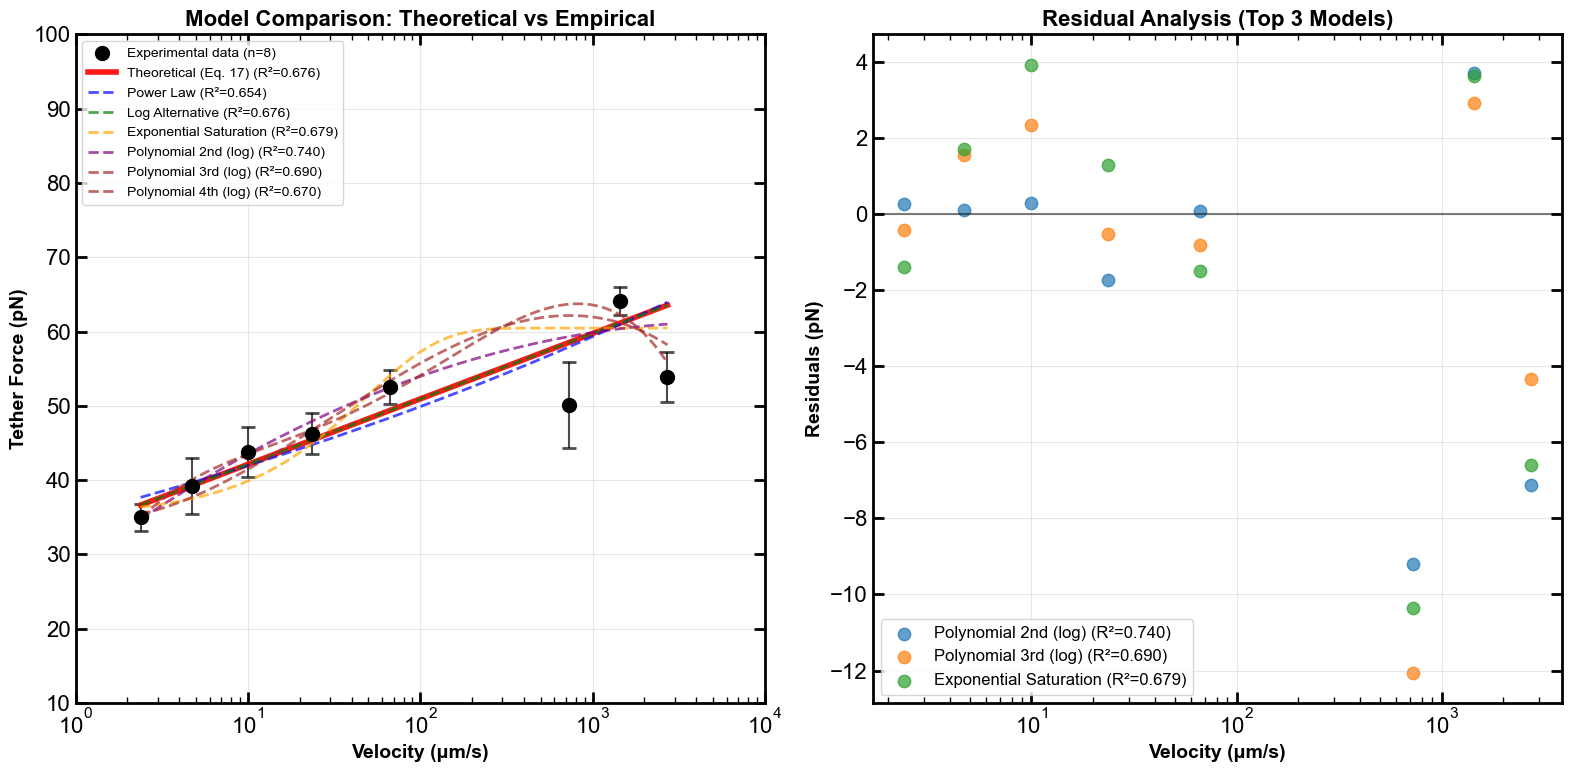


THEORETICAL MODEL ANALYSIS (Equation 17)
Model: F = A + B × ln(v)
A (static force term) = 33.31 ± 1.65 pN
B (logarithmic coefficient) = 3.83 ± 0.35 pN
R² = 0.6763
Reduced χ² = 2.684

PHYSICAL INTERPRETATION:
• Static force (f₀): 33.3 pN
• Velocity sensitivity: 3.8 pN per ln(v) decade
• Good fit quality: χ²_red ≈ 1 indicates optimal fit ⚠

FORCE PREDICTIONS:
At v =    1 μm/s: F = 33.3 pN
At v =   10 μm/s: F = 42.1 pN
At v =  100 μm/s: F = 50.9 pN
At v = 1000 μm/s: F = 59.7 pN

MODEL RANKING (by R²)
1. 📊 Polynomial 2nd (log)      R² = 0.7396
2. 📊 Polynomial 3rd (log)      R² = 0.6903
3. 📊 Exponential Saturation    R² = 0.6790
4. 🧬 Theoretical (Eq. 17)      R² = 0.6763
5. 📊 Log Alternative           R² = 0.6763
6. 📊 Polynomial 4th (log)      R² = 0.6705
7. 📊 Power Law                 R² = 0.6545

RECOMMENDATIONS
❌ ALL MODELS SHOW POOR FIT
   • R² < 0.95 suggests missing physics
   • Consider additional parameters or different model
   • Check for experimental artifacts

Theoretical vs Be

In [56]:
# =================================================================
# VISUALIZATION: COMPARE ALL MODELS
# =================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: All models
ax1.scatter(x_data, y_data, color='black', s=100, zorder=10, 
           label=f'Experimental data (n={len(x_data)})')
ax1.errorbar(x_data, y_data, yerr=y_errors, fmt='none', 
            color='black', capsize=5, capthick=2, alpha=0.7)

# Plot all successful models
for name, result in successful_models.items():
    model_info = models[name]
    if model_info.get('theory', False):
        # Highlight theoretical model
        ax1.plot(x_smooth, result['y_smooth'], 
                color=model_info['color'], linewidth=model_info['linewidth'],
                label=f"{name} (R²={result['r2']:.3f})", linestyle='-', alpha=0.9)
    else:
        ax1.plot(x_smooth, result['y_smooth'], 
                color=model_info['color'], linewidth=model_info['linewidth'],
                label=f"{name} (R²={result['r2']:.3f})", linestyle='--', alpha=0.7)

ax1.set_xscale('log')
ax1.set_xlabel('Velocity (μm/s)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Tether Force (pN)', fontsize=14, fontweight='bold')
ax1.set_title('Model Comparison: Theoretical vs Empirical', fontsize=16, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, 10000)
ax1.set_ylim(10, 100)

# Right plot: Residuals for best models
best_models = sorted(successful_models.items(), key=lambda x: x[1]['r2'], reverse=True)[:3]

for i, (name, result) in enumerate(best_models):
    residuals = y_data - result['y_pred']
    ax2.scatter(x_data, residuals, label=f"{name} (R²={result['r2']:.3f})", 
               s=80, alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax2.set_xscale('log')
ax2.set_xlabel('Velocity (μm/s)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Residuals (pN)', fontsize=14, fontweight='bold')
ax2.set_title('Residual Analysis (Top 3 Models)', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================
# DETAILED ANALYSIS OF THEORETICAL MODEL
# =================================================================

if 'Theoretical (Eq. 17)' in successful_models:
    theo_result = successful_models['Theoretical (Eq. 17)']
    A, B = theo_result['params']
    A_err, B_err = theo_result['param_errors']
    
    print("\n" + "="*60)
    print("THEORETICAL MODEL ANALYSIS (Equation 17)")
    print("="*60)
    print(f"Model: F = A + B × ln(v)")
    print(f"A (static force term) = {A:.2f} ± {A_err:.2f} pN")
    print(f"B (logarithmic coefficient) = {B:.2f} ± {B_err:.2f} pN")
    print(f"R² = {theo_result['r2']:.4f}")
    print(f"Reduced χ² = {theo_result['chi2_red']:.3f}")
    print()
    print("PHYSICAL INTERPRETATION:")
    print(f"• Static force (f₀): {A:.1f} pN")
    print(f"• Velocity sensitivity: {B:.1f} pN per ln(v) decade")
    print(f"• Good fit quality: χ²_red ≈ 1 indicates optimal fit" + 
          (" ✓" if 0.5 <= theo_result['chi2_red'] <= 2 else " ⚠"))
    
    # Predict forces at specific velocities
    print("\nFORCE PREDICTIONS:")
    test_velocities = [1, 10, 100, 1000]
    for v in test_velocities:
        F_pred = A + B * np.log(v)
        print(f"At v = {v:4d} μm/s: F = {F_pred:.1f} pN")

# =================================================================
# MODEL RANKING AND RECOMMENDATIONS
# =================================================================

print("\n" + "="*60)
print("MODEL RANKING (by R²)")
print("="*60)

ranked_models = sorted(successful_models.items(), key=lambda x: x[1]['r2'], reverse=True)

for i, (name, result) in enumerate(ranked_models, 1):
    is_theoretical = models[name].get('theory', False)
    marker = "🧬" if is_theoretical else "📊"
    print(f"{i}. {marker} {name:<25} R² = {result['r2']:.4f}")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

best_model = ranked_models[0]
best_name, best_result = best_model

if 'Theoretical' in best_name:
    print("✅ THEORETICAL MODEL IS BEST FIT!")
    print("   • Use Equation 17: F = A + B × ln(v)")
    print("   • Physically meaningful parameters")
    print("   • Based on molecular theory")
    print("   • Can extrapolate beyond measured range")
elif best_result['r2'] > 0.95:
    print(f"⚠️  EMPIRICAL MODEL ({best_name}) fits slightly better")
    print("   • Higher R² but may be overfitting")
    print("   • Consider theoretical model for physical insight")
    print("   • Use empirical for interpolation only")
else:
    print("❌ ALL MODELS SHOW POOR FIT")
    print("   • R² < 0.95 suggests missing physics")
    print("   • Consider additional parameters or different model")
    print("   • Check for experimental artifacts")

# Theoretical vs best empirical comparison
if 'Theoretical (Eq. 17)' in successful_models and best_name != 'Theoretical (Eq. 17)':
    theo_r2 = successful_models['Theoretical (Eq. 17)']['r2']
    best_r2 = best_result['r2']
    diff = best_r2 - theo_r2
    print(f"\nTheoretical vs Best Empirical:")
    print(f"R² difference: {diff:.4f} ({'negligible' if diff < 0.01 else 'significant'})")